In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import pmdarima as pm
import arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy import optimize

# 데이터 불러오기
original = pd.read_csv('c:\python\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])
print(original.head())

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52

def holt_winters(x, alpha, theta=None, exog=None, initial_level=None):
    """
    Holt-Winters Exponential Smoothing Algorithm with Exogenous Variables
    """
    """
    Holt-Winters Exponential Smoothing Algorithm with Exogenous Variables
    Parameters:
        x (array-like): Time series data
        alpha (float): Level smoothing coefficient (0 < alpha < 1)
        beta (float): Trend smoothing coefficient (0 < beta < 1)
        gamma (float): Seasonal smoothing coefficient (0 < gamma < 1)
        period (int): Seasonal period
        theta (array-like): Coefficients for exogenous variables
        exog (array-like): Exogenous variables (2D array, rows=time periods, cols=variables)
        seasonal (str): "additive" or "multiplicative"
    
    Returns:
        dict: Contains 'fitted', 'level', 'trend', 'seasonal', 'SSE'
    """
    n = len(x)
    
    # 초기화
    level = np.zeros(n+1)
    fitted = np.zeros(n+1)
    SSE = 0

    # 외생변수 영향 계산
    exog_effect = np.zeros(n)
    if exog is not None and theta is not None:
        exog_effect = np.dot(exog, theta)

    # === 초기값 자동 추정 ===
    level[0] = initial_level

    # Holt-Winters 지수 평활법 적용
    for t in range(n):
        
        # fitted는 level[t]에 해당 (시점 t에서의 예측값)
        fitted[t] = level[t]

        # 오차 계산
        error = x.iloc[t] - fitted[t]
        SSE += error**2

        # 다음 레벨 계산
        exog_term = exog_effect[t] if exog is not None else 0
        level[t + 1] = alpha * x.iloc[t] + (1 - alpha) * (level[t] + exog_term)
    
    fitted[n] = level[n]
    
    return {
        "fitted": fitted,
        "level": level,
        "SSE": SSE
    }

def objective_function_fixed_alpha(params, x, alpha, exog=None):
    
    # 외생변수 계수 (있는 경우)
    theta = None
    if exog is not None and len(params) > 2:
        theta = params[2:]
    
    # Holt-Winters 수행
    result = holt_winters(x, alpha, theta, exog)
    
    return result["SSE"]

def optimize_hw_parameters_fixed_alpha(x, alpha=0.1, exog=None, initial_params=None, initial_level=None):
    # 초기값 (beta, gamma)
    if initial_params is None:
        initial_params = [0.1, 0.3]
        if exog is not None:
            initial_params.extend([0.1] * exog.shape[1])

    # bounds 설정
    bounds = [(0.001, 0.999)] * 2  # beta, gamma
    if exog is not None:
        bounds.extend([(-1e9, 1e9)] * exog.shape[1])

    # 최적화
    result = optimize.minimize(
        objective_function_fixed_alpha,
        initial_params,
        args=(x, alpha, exog),
        method='L-BFGS-B',
        bounds=bounds
    )

    theta = result.x[2:] if exog is not None else None

    model = holt_winters(x, alpha, theta, exog, initial_level)

    return {
        "alpha": alpha,
        "theta": theta,
        "SSE": model["SSE"],
        "fitted": model["fitted"],
        "level": model["level"],
        "optimization_result": result,
    }



     HS10단위부호       수리일자 무역거래처국가코드     신고중량  과세가격미화금액    연도  월  주차   연도주차
0  8542391000 2017-01-01        SG   64.652     59061  2017  1  52  17_52
1  6109101000 2017-01-01        US    0.680        50  2017  1  52  17_52
2  8481801090 2017-01-01        US    9.100      2205  2017  1  52  17_52
3  7318159000 2017-01-02        BE  128.534      3210  2017  1   1  17_01
4  8479909090 2017-01-02        CN 3043.295    166420  2017  1   1  17_01


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_40주차
📌 estimated initial_level: 0.28193
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0832
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.273
1    0.276
2    0.277
3    0.278
4    0.281
5    0.284
6    0.285
7    0.285
8    0.287
9    0.287
10   0.302
11   0.307
12   0.308
13   0.310
14   0.304
15   0.304
16   0.306
17   0.310
18   0.312
19   0.320
20   0.329
21   0.332
22   0.341
23   0.347
24   0.351
25   0.360
26   0.366
27   0.367
28   0.368
29   0.368
30   0.365
31   0.365
32   0.368
33   0.371
34   0.373
35   0.375
36   0.372
37   0.387
38   0.398


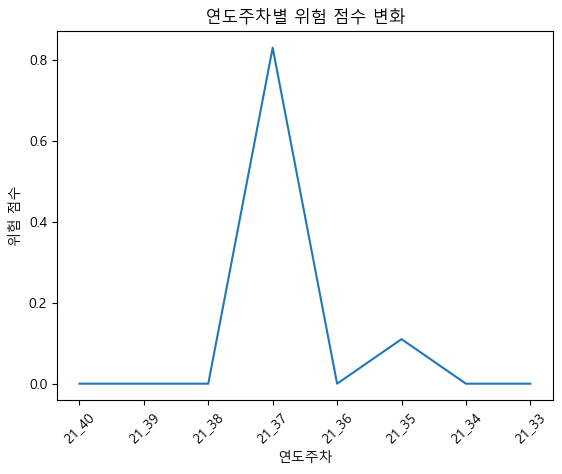

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_30주차
📌 estimated initial_level: 248.65493
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 33636.2661
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    232.394
1    239.664
2    243.658
3    241.069
4    270.627
5    241.770
6    275.102
7    270.882
8    274.426
9    273.856
10   243.639
11   240.823
12   231.794
13   251.146
14   277.998
15   272.614
16   292.676
17   274.076
18   287.220
19   326.250
20   296.285
21   286.282
22   246.525
23   210.616
24   234.737
25   244.200
26   254.369
27   261.244
28   261.333
29   265.613
30   314.574
31   282.201
32   294.642
33   3

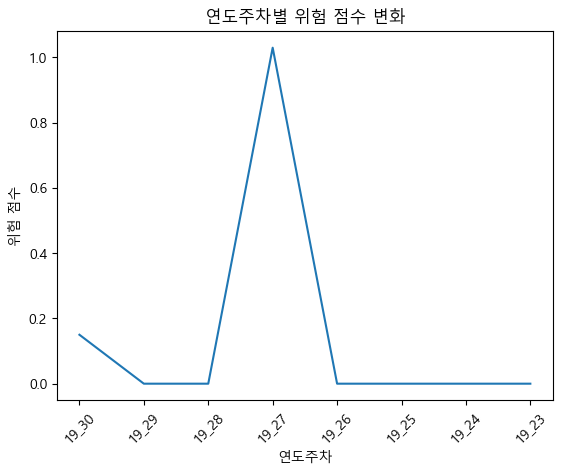

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
21_14주차
📌 estimated initial_level: 1.24965
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0971
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    1.168
1    1.273
2    1.278
3    1.296
4    1.307
5    1.282
6    1.246
7    1.225
8    1.222
9    1.217
10   1.240
11   1.241
12   1.239
13   1.256
14   1.291
15   1.279
16   1.276
17   1.256
18   1.236
19   1.272
20   1.268
21   1.283
22   1.301
23   1.275
24   1.316
25   1.192
26   1.178
27   1.191
28   1.172
29   1.283
30   1.298
31   1.299
32   1.309
33   1.323
34   1.315
35   1.257
36   1.252
37   1.248
38   1.271
39   1.309
40   1.326
41

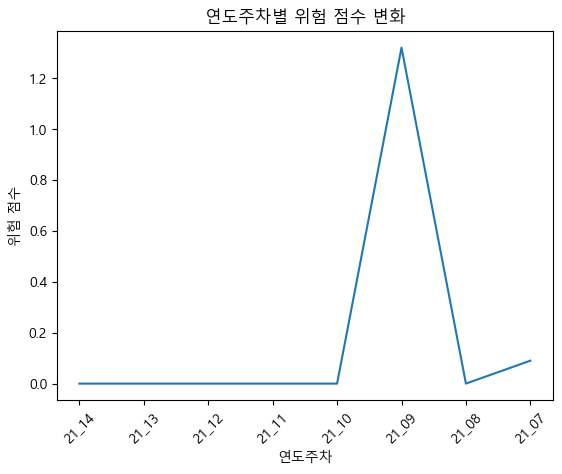

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_45주차
📌 estimated initial_level: 1.62845
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 15.0849
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    1.529
1    1.524
2    1.523
3    1.519
4    1.540
5    1.577
6    1.619
7    1.670
8    1.729
9    1.849
10   1.911
11   1.981
12   2.053
13   2.281
14   2.331
15   2.448
16   2.445
17   2.461
18   2.481
19   2.490
20   2.479
21   2.496
22   2.483
23   2.499
24   2.559
25   2.567
26   2.589
27   2.603
28   2.582
29   2.566
30   2.541
31   2.551
32   2.547
33   2.577
34   2.583
35   2.612
36   2.658
37   2.695
38   2.774
39   2.806


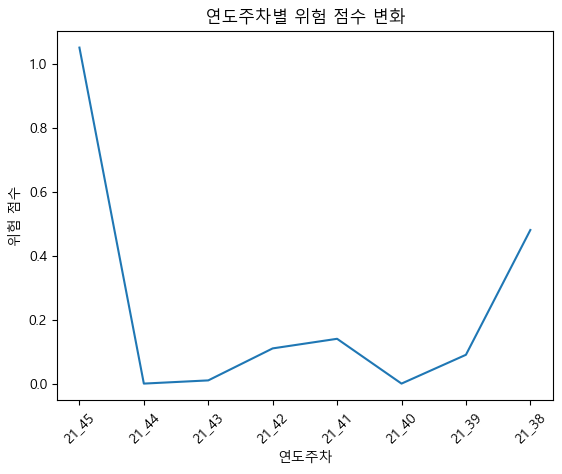

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_51주차
📌 estimated initial_level: 0.11203
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0527
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.103
1    0.107
2    0.107
3    0.110
4    0.113
5    0.116
6    0.116
7    0.126
8    0.122
9    0.119
10   0.127
11   0.123
12   0.136
13   0.134
14   0.131
15   0.127
16   0.116
17   0.115
18   0.130
19   0.130
20   0.130
21   0.131
22   0.120
23   0.128
24   0.134
25   0.134
26   0.137
27   0.138
28   0.134
29   0.133
30   0.151
31   0.167
32   0.174
33   0.184
34   0.187
35   0.196
36   0.192
37   0.191

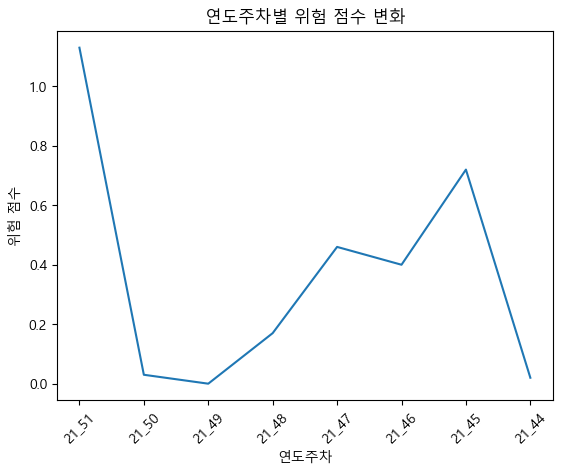

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_51주차
📌 estimated initial_level: 3.12891
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 18.9340
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    2.941
1    3.446
2    3.332
3    3.499
4    3.310
5    2.799
6    2.863
7    2.831
8    2.821
9    2.890
10   2.824
11   2.865
12   2.883
13   2.876
14   2.908
15   2.917
16   2.906
17   2.891
18   2.912
19   2.931
20   2.909
21   2.869
22   2.830
23   2.816
24   2.820
25   2.829
26   2.819
27   2.800
28   2.900
29   2.929
30   2.988
31   3.028
32   3.024
33   3.037
34   3.074
35   3.121
36   3.081
37   3.062
38   3.018
39   3.040
40   3.063
4

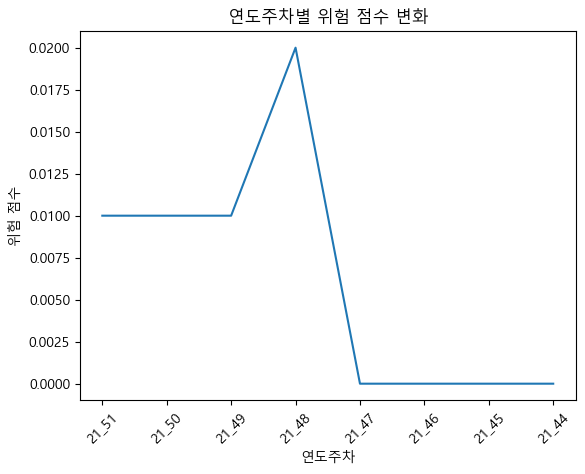

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
22_02주차
📌 estimated initial_level: 0.98512
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.2488
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.938
1    0.929
2    0.964
3    0.970
4    1.038
5    1.039
6    1.047
7    1.055
8    1.030
9    1.030
10   1.033
11   1.022
12   1.038
13   1.037
14   1.030
15   1.036
16   1.043
17   1.050
18   1.048
19   1.040
20   1.088
21   1.083
22   1.091
23   1.091
24   1.162
25   1.105
26   1.101
27   1.101
28   1.102
29   1.106
30   1.106
31   1.109
32   1.108
33   1.101
34   1.080
35   1.079
36   1.080
37   1.099
38   1.122
39   1.122
4

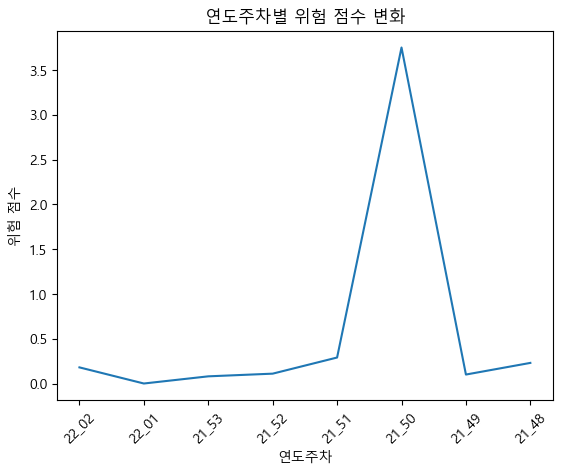

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 10.05989
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 10.4376
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    10.195
1    10.037
2    10.390
3    10.453
4    10.162
5     9.852
6     9.621
7     9.196
8     9.350
9     9.638
10   10.013
11    9.977
12   10.147
13   10.167
14    9.490
15    9.620
16    9.601
17    9.705
18   10.421
19   10.462
20   10.554
21   10.553
22   10.477
23   10.527
24   10.073
25   10.360
26   10.401
27   10.182
28   10.092
29    9.916
30    9.802
31   10.003
32   10.436
33   10.247
34    9.902
35    9.951
36   10.

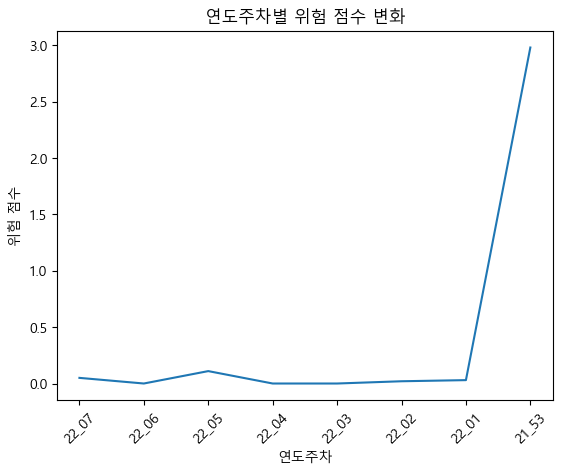

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
22_08주차
📌 estimated initial_level: 10.19757
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 34.9485
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     9.300
1     9.672
2     9.979
3    10.184
4    10.329
5    10.529
6    10.716
7    10.961
8    11.144
9    11.442
10   11.862
11   12.057
12   11.951
13   11.591
14   11.142
15   10.882
16   10.815
17   10.860
18   10.877
19   10.978
20   11.150
21   11.291
22   11.276
23   10.982
24   10.477
25    9.980
26    9.511
27    9.247
28    9.175
29    9.185
30    9.278
31    9.490
32    9.675
33    9.960
34   10.165
35   10.085
36    9.

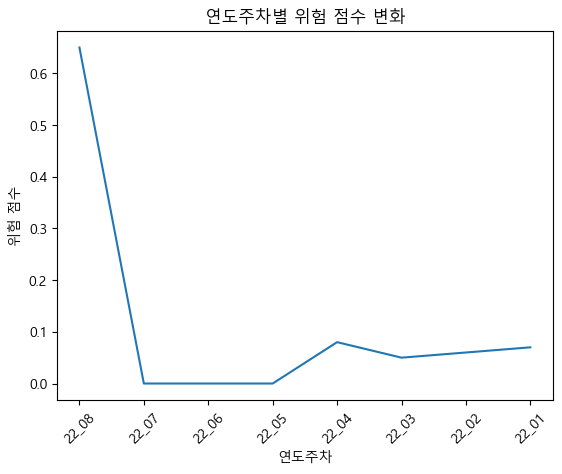

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 0.21748
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0026
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.216
1    0.217
2    0.217
3    0.217
4    0.217
5    0.216
6    0.216
7    0.216
8    0.216
9    0.223
10   0.225
11   0.227
12   0.224
13   0.216
14   0.222
15   0.222
16   0.224
17   0.226
18   0.224
19   0.231
20   0.228
21   0.230
22   0.228
23   0.223
24   0.225
25   0.219
26   0.219
27   0.220
28   0.220
29   0.220
30   0.220
31   0.227
32   0.233
33   0.232
34   0.233
35   0.229
36   0.229
37   0.240
38   0.240
39   0.247
4

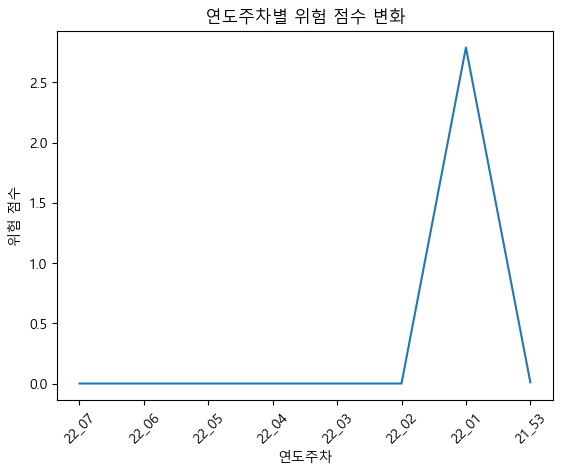

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 0.25075
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0229
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.244
1    0.239
2    0.236
3    0.247
4    0.254
5    0.254
6    0.246
7    0.256
8    0.283
9    0.283
10   0.283
11   0.282
12   0.278
13   0.272
14   0.272
15   0.269
16   0.281
17   0.293
18   0.293
19   0.287
20   0.268
21   0.269
22   0.269
23   0.277
24   0.279
25   0.289
26   0.271
27   0.266
28   0.264
29   0.264
30   0.267
31   0.279
32   0.286
33   0.281
34   0.288
35   0.281
36   0.281
37   0.291
38   0.278
39   0.284
4

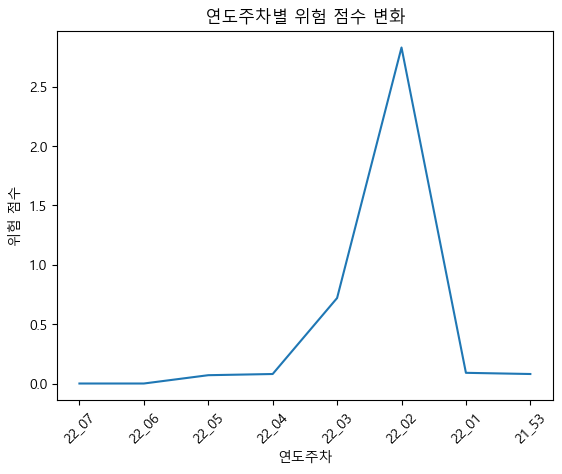

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 0.4113
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0030
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.415
1    0.410
2    0.404
3    0.412
4    0.411
5    0.414
6    0.410
7    0.424
8    0.414
9    0.418
10   0.420
11   0.408
12   0.414
13   0.407
14   0.405
15   0.392
16   0.392
17   0.392
18   0.394
19   0.394
20   0.396
21   0.397
22   0.395
23   0.395
24   0.394
25   0.394
26   0.396
27   0.397
28   0.397
29   0.405
30   0.407
31   0.411
32   0.411
33   0.411
34   0.412
35   0.410
36   0.411
37   0.410
38   0.410
39   0.411
40   0.409
41 

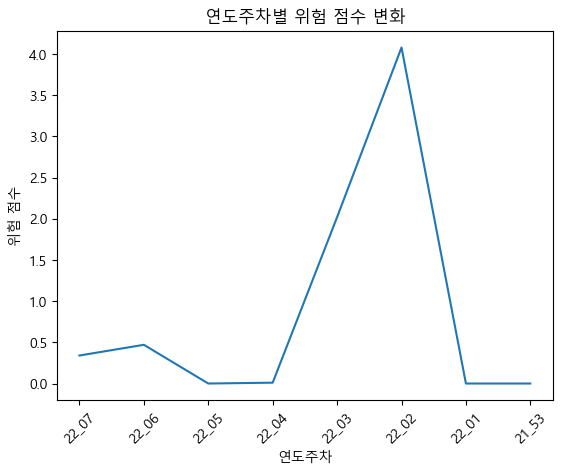

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 0.60281
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.2430
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.557
1    0.587
2    0.587
3    0.598
4    0.633
5    0.647
6    0.646
7    0.642
8    0.633
9    0.622
10   0.633
11   0.634
12   0.663
13   0.658
14   0.527
15   0.571
16   0.570
17   0.559
18   0.679
19   0.687
20   0.724
21   0.730
22   0.733
23   0.733
24   0.732
25   0.782
26   0.663
27   0.663
28   0.665
29   0.679
30   0.692
31   0.695
32   0.692
33   0.707
34   0.735
35   0.758
36   0.879
37   0.838
38   0.827


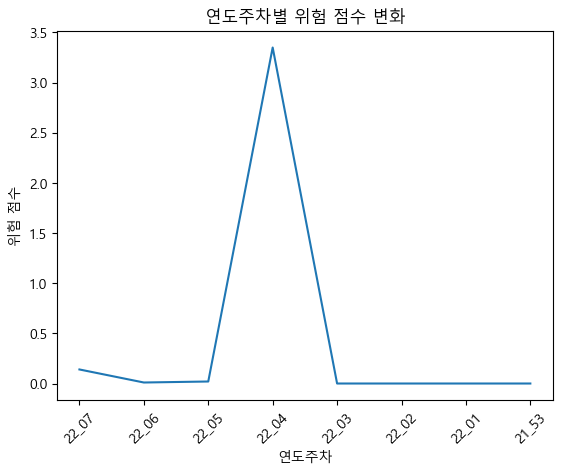

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
22_07주차
📌 estimated initial_level: 0.26972
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.2870
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.265
1    0.271
2    0.268
3    0.272
4    0.261
5    0.260
6    0.260
7    0.260
8    0.299
9    0.280
10   0.279
11   0.280
12   0.276
13   0.299
14   0.283
15   0.283
16   0.278
17   0.278
18   0.274
19   0.280
20   0.286
21   0.288
22   0.295
23   0.343
24   0.356
25   0.368
26   0.368
27   0.369
28   0.388
29   0.389
30   0.369
31   0.372
32   0.363
33   0.353
34   0.355
35   0.380
36   0.380
37   0.533
38   0.445


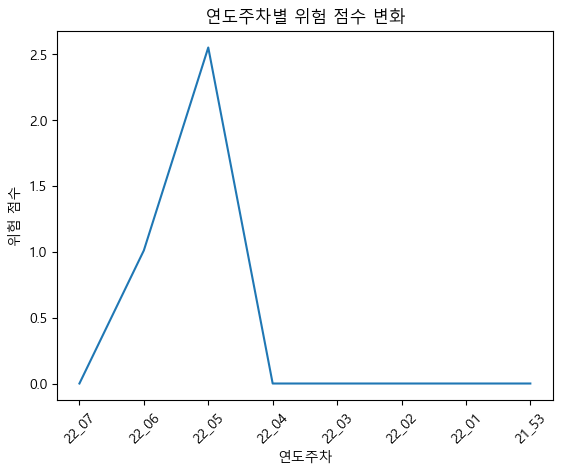

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
22_16주차
📌 estimated initial_level: 2.0094
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1.6225
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    1.868
1    1.884
2    1.888
3    1.972
4    1.982
5    2.164
6    2.211
7    2.363
8    2.266
9    2.237
10   2.206
11   2.106
12   2.144
13   2.074
14   2.136
15   2.217
16   2.281
17   2.268
18   2.303
19   2.208
20   2.411
21   2.438
22   2.393
23   2.378
24   2.260
25   2.278
26   2.390
27   2.436
28   2.515
29   2.421
30   2.293
31   2.319
32   2.320
33   2.359
34   2.538
35   2.443
36   2.374
37   2.305
38   2.150
39   2.380
40   2.506
41 

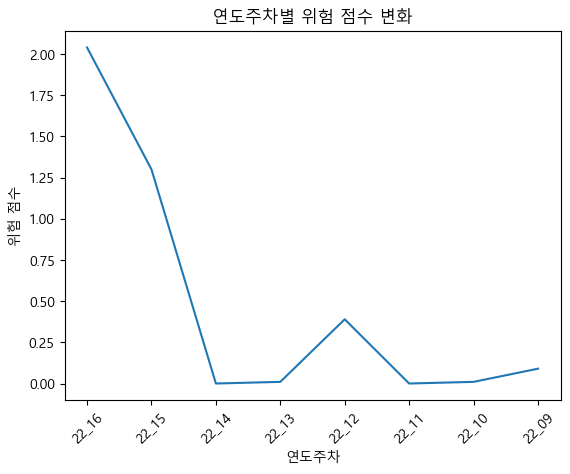

[np.float64(0.83), np.float64(1.03), np.float64(1.32), np.float64(1.05), np.float64(1.13), np.float64(0.02), np.float64(3.75), np.float64(2.98), np.float64(0.65), np.float64(2.79), np.float64(2.83), np.float64(4.08), np.float64(3.35), np.float64(2.55), np.float64(2.04)]
[54, 169, 82, 46, 40, 43, 41, 38, 30, 37, 36, 36, 34, 33, 22]


In [2]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]


z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)
      
   
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 Exponential Smoothing 구하기 ====================
        res_resid = df_price_4w['단가'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop = True)
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
        
        model = ExponentialSmoothing(train, initialization_method="estimated")
        model_fit = model.fit(smoothing_level=0.2)
        estimated_level = round(model_fit.params["initial_level"], 5)
        print("📌 estimated initial_level:", estimated_level)
            
        print("최적화 (외생변수 없음):")
        result1 = optimize_hw_parameters_fixed_alpha(train, initial_level = estimated_level)
        print(f"최적 alpha: {result1['alpha']:.4f}")
        print(f"최소 SSE: {result1['SSE']:.4f}")

             
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = train - result1['fitted'][:-1]
        #est_residuals = model_fit.resid
        print("📌📌", train)
        print("📌📌", est_residuals)
        
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
               
        stand_quant = (test.iloc[0] - result1['fitted'][-1]) / garch_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        print("📌",test.iloc[0])
        print("📌",result1['fitted'])
        print("📌",result1['fitted'][-1])
        print("📌",garch_std)
        print("📌", y)

      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop = True)
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
       
        model = ExponentialSmoothing(train, initialization_method="estimated")
        model_fit = model.fit(smoothing_level=0.2)
        estimated_level = round(model_fit.params["initial_level"], 5)
        print("📌 estimated initial_level:", estimated_level)
            
        print("최적화 (외생변수 없음):")
        result1 = optimize_hw_parameters_fixed_alpha(train, initial_level = estimated_level)
        print(f"최적 alpha: {result1['alpha']:.4f}")
        print(f"최소 SSE: {result1['SSE']:.4f}")

              
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = train - result1['fitted'][:-1]
        #est_residuals = model_fit.resid
        
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
               
        stand_quant = (test.iloc[0] - result1['fitted'][-1]) / garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y

    if(z[j]>1.85):
        o[j] = 1      
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model8(1)'] = o
collect.loc[15, 'Model8(1)'] = np.sum(o)
collect.loc[:14, 'Model8(2)'] = z
collect.loc[15, 'Model8(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[9]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[9]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[9]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
📌 estimated initial_level: 12.37673
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 47.5800
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    12.129
1    11.984
2    12.347
3    11.683
4    12.158
5    12.330
6    12.285
7    12.515
8    13.271
9    13.807
10   14.311
11   15.821
12   14.435
13   13.925
14   13.304
15   12.550
16   12.274
17   11.901
18   11.674
19   11.701
20   11.671
21   11.323
22   11.439
23   11.235
24   11.117
25   11.300
26   11.127
27   11.482
28   12.033
29   12.253
30   12.344
31   12.359
32   12.300
33   12.373
34   12.857
35   12.908
36   12.585
37   12.790
38   12.298
39   13.513
40   14.026
41   14.352
42   14.920
43   13.624
44   13.439
45   12.984
46   12.977
47   13.023
48   12.822
49   12.741
50   12.760
Name: 단가, dtype: float64
📌📌 0    -0.248
1    -0.368
2     0.031
3    -0.636
4    -0.097
5     0.085
6     0.032
7     0.258
8     0.989
9     1.426
10    1.787
11    3.119
12    1.420
13    0.768
14 

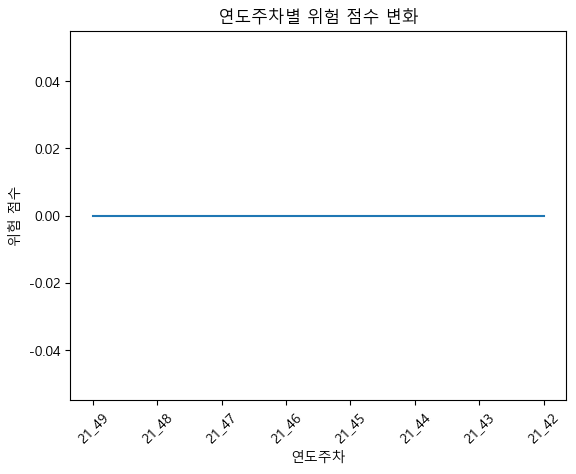

HS Code : 7326909000
21_49주차
📌 estimated initial_level: 4.10309
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1.7876
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    3.834
1    3.985
2    4.133
3    4.049
4    4.178
5    4.165
6    4.174
7    4.239
8    4.336
9    4.360
10   4.582
11   4.783
12   4.699
13   4.419
14   4.331
15   4.257
16   4.197
17   4.334
18   4.160
19   4.222
20   4.080
21   4.029
22   4.205
23   4.097
24   4.330
25   4.476
26   4.382
27   4.371
28   4.282
29   4.434
30   4.414
31   4.308
32   4.474
33   4.490
34   4.532
35   4.701
36   4.380
37   4.060
38   4.080
39   4.143
40   4.257
41   4.221
42   4.220
43   4.160
44   4.188
45   4.201
46   4.087
47   4.143
48   4.173
49   4.280
50   4.135
Name: 단가, dtype: float64
📌📌 0    -0.269
1    -0.092
2     0.066
3    -0.024
4     0.107
5     0.084
6     0.084
7     0.140
8     0.224
9     0.225
10    0.425
11    0.583
12    0.441
13    0.116
14    0.017
15   -0.059
16   -0.113
17    0.036
18   -0.

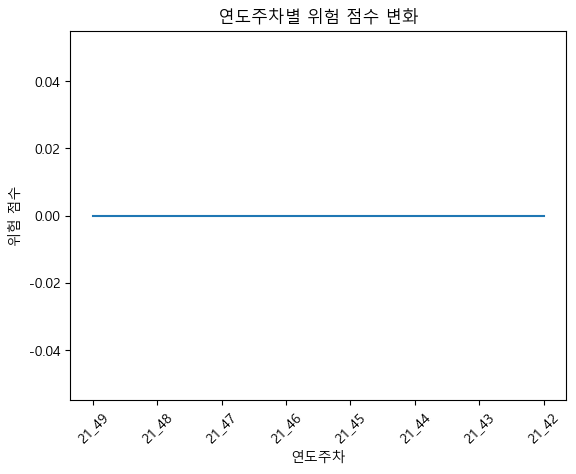

HS Code : 8708999000
21_49주차
📌 estimated initial_level: 14.69043
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 16.2774
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    14.864
1    14.780
2    14.506
3    14.466
4    14.632
5    14.446
6    14.692
7    14.774
8    14.350
9    14.510
10   14.644
11   15.057
12   15.278
13   15.356
14   14.923
15   14.652
16   15.201
17   15.301
18   15.140
19   15.478
20   14.721
21   14.850
22   15.336
23   14.648
24   14.531
25   14.007
26   13.881
27   14.143
28   14.621
29   14.497
30   14.400
31   14.131
32   13.859
33   14.443
34   14.132
35   14.716
36   14.272
37   13.614
38   14.205
39   13.951
40   14.120
41   14.038
42   14.460
43   14.996
44   15.642
45   16.467
46   15.027
47   14.686
48   13.669
49   13.437
50   13.527
Name: 단가, dtype: float64
📌📌 0     0.173
1     0.072
2    -0.209
3    -0.228
4    -0.039
5    -0.222
6     0.046
7     0.124
8    -0.313
9    -0.121
10    0.025
11    0.436
12    0.613
13    0.630
14 

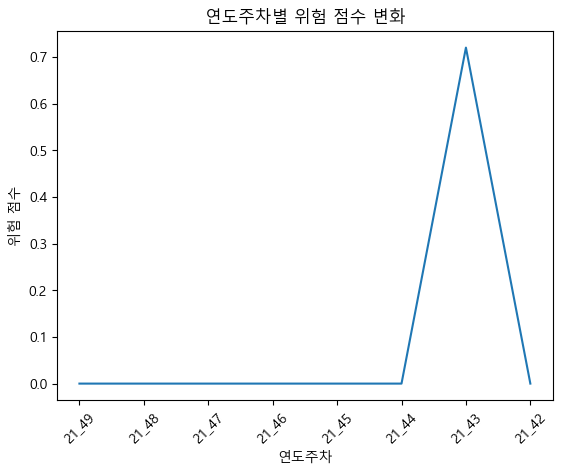

HS Code : 2106909099
21_49주차
📌 estimated initial_level: 27.30682
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 222.6048
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    30.593
1    28.459
2    27.590
3    24.369
4    24.924
5    26.267
6    26.436
7    27.241
8    25.988
9    26.008
10   25.668
11   27.228
12   26.945
13   26.874
14   25.740
15   23.675
16   23.194
17   22.879
18   22.957
19   24.092
20   25.188
21   24.300
22   26.033
23   25.691
24   23.988
25   23.960
26   22.640
27   22.399
28   23.656
29   22.847
30   22.755
31   23.143
32   22.483
33   22.269
34   23.032
35   21.742
36   22.539
37   24.902
38   26.445
39   28.277
40   29.857
41   27.695
42   27.241
43   28.329
44   26.939
45   28.766
46   27.940
47   27.826
48   28.926
49   28.200
50   29.259
Name: 단가, dtype: float64
📌📌 0     3.286
1     0.823
2    -0.128
3    -3.336
4    -2.448
5    -0.859
6    -0.605
7     0.261
8    -1.018
9    -0.897
10   -1.147
11    0.528
12    0.192
13    0.102
14

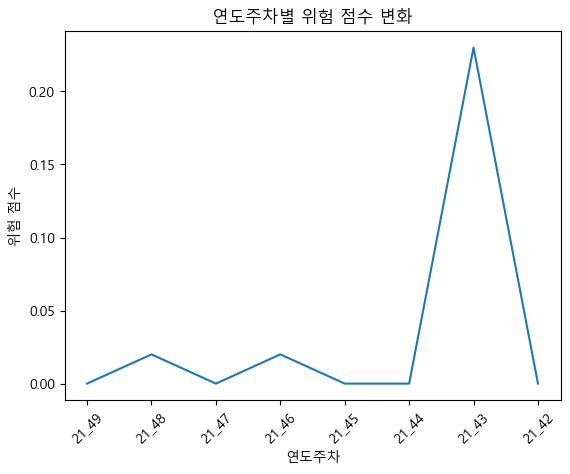

HS Code : 4911990000
21_49주차
📌 estimated initial_level: 27.71419
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 8955.3358
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    31.889
1    26.694
2    20.066
3    27.773
4    28.758
5    34.575
6    28.508
7    19.205
8    20.105
9    15.976
10   18.177
11   36.025
12   46.020
13   38.914
14   44.076
15   32.960
16   25.394
17   37.994
18   28.626
19   36.832
20   37.516
21   31.605
22   36.665
23   22.455
24   29.634
25   26.087
26   26.901
27   45.386
28   49.568
29   56.153
30   65.112
31   77.807
32   70.767
33   68.448
34   47.387
35   25.319
36   24.198
37   24.514
38   36.792
39   34.226
40   22.457
41   23.756
42   20.052
43   21.737
44   28.928
45   28.451
46   24.885
47   35.497
48   32.926
49   30.967
50   38.114
Name: 단가, dtype: float64
📌📌 0      4.174
1     -1.438
2     -7.922
3      0.577
4      1.504
5      7.171
6      0.387
7     -8.955
8     -7.160
9    -10.573
10    -7.314
11    11.265
12    20.134


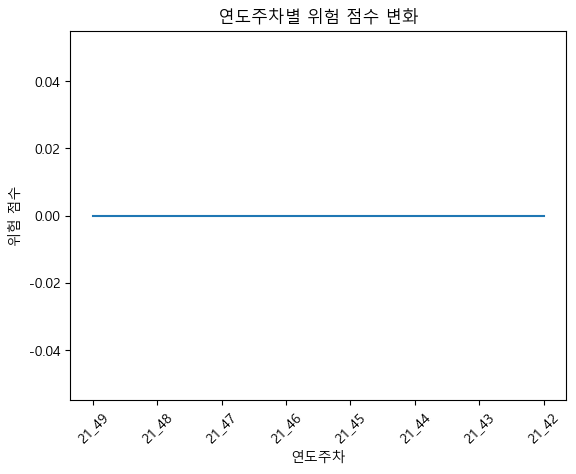

HS Code : 6403999000
21_49주차
📌 estimated initial_level: 58.52308
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1528.5483
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    56.651
1    57.430
2    61.704
3    59.156
4    58.785
5    56.215
6    55.136
7    53.046
8    53.916
9    55.969
10   60.142
11   69.866
12   73.783
13   73.991
14   68.629
15   66.752
16   64.875
17   64.729
18   65.305
19   60.903
20   61.623
21   57.752
22   54.839
23   57.454
24   53.092
25   53.606
26   54.857
27   54.729
28   57.214
29   60.208
30   61.342
31   62.758
32   61.777
33   62.208
34   60.837
35   55.581
36   53.511
37   48.890
38   48.163
39   48.104
40   49.620
41   51.017
42   51.319
43   52.885
44   55.537
45   58.611
46   58.966
47   60.728
48   58.845
49   56.422
50   55.847
Name: 단가, dtype: float64
📌📌 0     -1.872
1     -0.906
2      3.459
3      0.565
4      0.137
5     -2.446
6     -3.281
7     -5.043
8     -3.668
9     -1.248
10     3.050
11    12.468
12    15.138


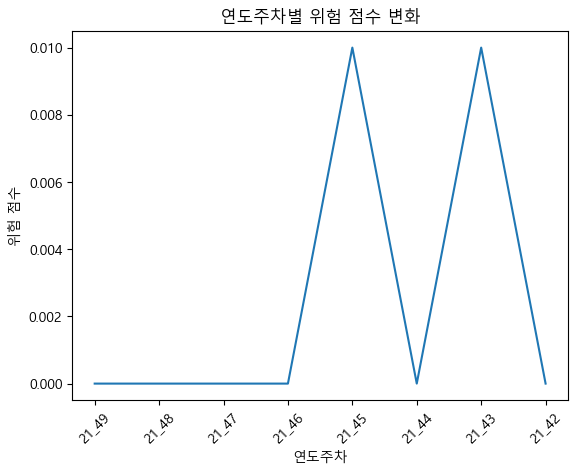

HS Code : 9031809099
21_49주차
📌 estimated initial_level: 129.10473
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20835.8328
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    118.813
1    130.360
2    144.109
3    139.926
4    131.068
5    120.233
6    110.134
7    113.228
8    116.638
9    119.542
10   126.038
11   172.230
12   168.641
13   158.830
14   162.813
15   127.183
16   138.774
17   132.574
18    99.811
19    99.872
20    90.912
21    96.972
22   130.949
23   141.057
24   132.804
25   137.055
26   134.151
27   119.467
28   110.096
29   104.505
30   116.429
31   126.678
32   162.260
33   178.553
34   159.912
35   160.643
36   148.701
37   135.297
38   135.422
39   123.892
40   120.175
41   112.424
42   111.989
43   116.235
44   112.779
45   130.123
46   117.327
47   127.949
48   132.913
49   125.392
50   137.810
Name: 단가, dtype: float64
📌📌 0    -10.292
1      2.284
2     15.805
3     10.041
4      0.180
5    -10.674
6    -19.706
7    -14.641
8     -9.766

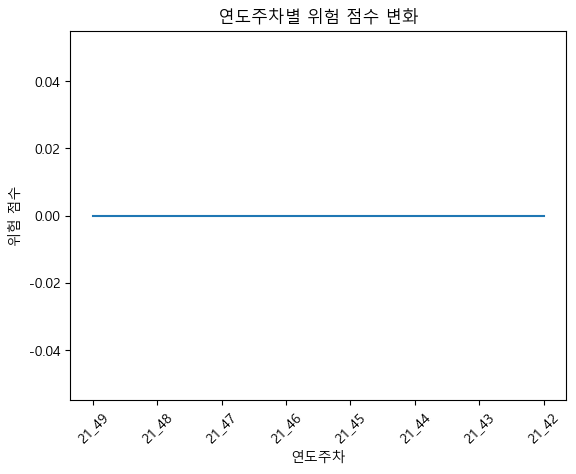

HS Code : 8542391000
21_49주차
📌 estimated initial_level: 2494.34319
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1528757.0883
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    2256.886
1    2242.619
2    2305.941
3    2781.164
4    2807.971
5    2761.921
6    2718.783
7    2557.276
8    2552.681
9    2749.718
10   2780.115
11   2647.720
12   2629.516
13   2468.133
14   2385.607
15   2466.182
16   2613.486
17   2703.610
18   2658.496
19   2801.852
20   2832.313
21   2719.244
22   2886.005
23   3027.613
24   2898.081
25   2923.625
26   2872.304
27   2555.152
28   2636.451
29   2869.053
30   2860.062
31   2879.000
32   2812.500
33   2607.264
34   2521.107
35   2405.614
36   2497.735
37   2528.978
38   2658.093
39   2616.743
40   2497.201
41   2465.869
42   2552.679
43   2662.523
44   2571.777
45   2676.266
46   2715.081
47   2634.333
48   2739.504
49   2821.855
50   2671.620
Name: 단가, dtype: float64
📌📌 0    -237.457
1    -227.978
2    -141.858
3     347.550
4     

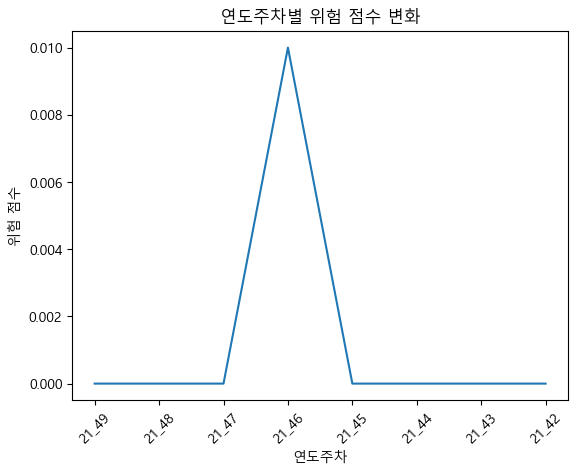

HS Code : 6109101000
21_49주차
📌 estimated initial_level: 24.51614
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 104.0001
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    23.925
1    25.071
2    26.246
3    25.052
4    24.693
5    24.251
6    23.896
7    24.105
8    24.540
9    24.040
10   23.204
11   23.723
12   23.581
13   22.758
14   22.995
15   21.824
16   20.911
17   21.489
18   21.456
19   21.403
20   21.996
21   21.933
22   22.313
23   22.951
24   22.849
25   22.531
26   22.500
27   23.974
28   24.004
29   24.344
30   24.130
31   24.132
32   24.172
33   24.955
34   23.940
35   22.848
36   22.947
37   21.375
38   21.525
39   20.103
40   19.431
41   19.184
42   19.041
43   19.373
44   20.153
45   20.896
46   21.317
47   21.456
48   21.058
49   21.662
50   22.473
Name: 단가, dtype: float64
📌📌 0    -0.591
1     0.614
2     1.728
3     0.361
4    -0.034
5    -0.473
6    -0.781
7    -0.494
8    -0.009
9    -0.508
10   -1.293
11   -0.645
12   -0.723
13   -1.473
14

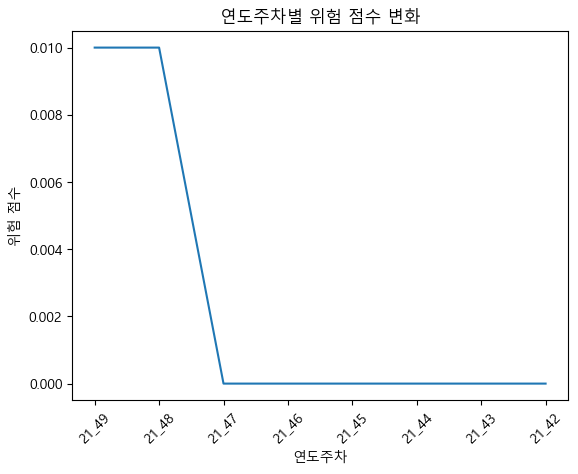

HS Code : 2934996000
21_49주차
📌 estimated initial_level: 20.9941
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 16181.2823
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     28.606
1     27.447
2     13.863
3     11.236
4     22.536
5     23.756
6     25.531
7     11.229
8      9.159
9      8.996
10     8.717
11    22.087
12    33.561
13    31.723
14    25.376
15    16.853
16    15.676
17    18.773
18    16.361
19    15.949
20    17.563
21    13.767
22    17.856
23    19.525
24    14.938
25    11.916
26    11.108
27    10.050
28    11.546
29    24.292
30    15.135
31    20.345
32    20.420
33    25.873
34    66.601
35    76.920
36    21.054
37    17.107
38    19.446
39    17.662
40   107.723
41    29.228
42    22.686
43    27.045
44    28.083
45    65.921
46    31.501
47    23.281
48    21.387
49    14.191
50    15.392
Name: 단가, dtype: float64
📌📌 0      7.612
1      5.692
2     -8.462
3    -10.242
4      2.082
5      3.093
6      4.559
7    -10.199
8    -11.249
9

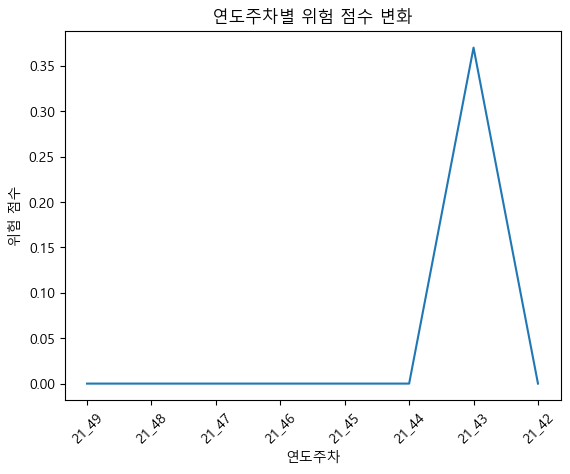

HS Code : 4016930000
21_49주차
📌 estimated initial_level: 37.73873
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 722.5319
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    34.964
1    36.334
2    36.767
3    38.210
4    38.089
5    36.646
6    39.592
7    38.335
8    36.446
9    40.501
10   40.052
11   45.578
12   49.965
13   50.065
14   46.072
15   42.161
16   43.278
17   42.829
18   45.216
19   44.219
20   44.366
21   41.591
22   42.556
23   44.247
24   41.460
25   41.786
26   40.328
27   39.917
28   38.604
29   38.424
30   41.718
31   41.623
32   43.638
33   48.012
34   44.963
35   44.949
36   44.890
37   44.164
38   45.132
39   43.587
40   42.196
41   37.635
42   38.165
43   39.788
44   42.177
45   45.030
46   44.373
47   39.100
48   35.789
49   35.687
50   31.437
Name: 단가, dtype: float64
📌📌 0    -2.775
1    -1.128
2    -0.582
3     0.920
4     0.707
5    -0.807
6     2.220
7     0.741
8    -1.223
9     2.955
10    2.211
11    7.515
12   11.150
13   10.136
14

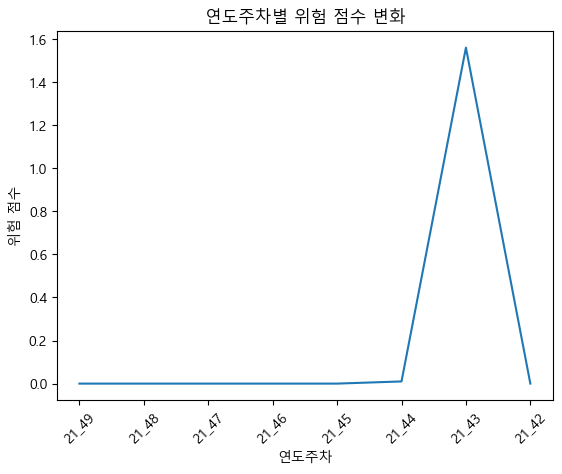

HS Code : 6110200000
21_49주차
📌 estimated initial_level: 30.53125
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 4226.2688
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    29.242
1    31.971
2    29.360
3    28.236
4    27.051
5    26.557
6    26.970
7    28.380
8    30.147
9    31.425
10   34.940
11   39.486
12   40.695
13   41.860
14   43.280
15   40.787
16   43.373
17   45.237
18   47.186
19   53.835
20   56.008
21   59.799
22   57.506
23   59.377
24   58.055
25   51.578
26   52.098
27   48.919
28   42.901
29   43.594
30   38.884
31   36.076
32   32.105
33   30.618
34   28.697
35   28.287
36   28.307
37   27.167
38   27.181
39   25.334
40   25.229
41   24.506
42   23.943
43   24.304
44   24.689
45   25.488
46   26.261
47   28.087
48   28.842
49   29.952
50   29.433
Name: 단가, dtype: float64
📌📌 0     -1.289
1      1.568
2     -1.199
3     -2.203
4     -3.168
5     -3.345
6     -2.598
7     -0.928
8      0.931
9      2.116
10     5.420
11     9.424
12     9.690


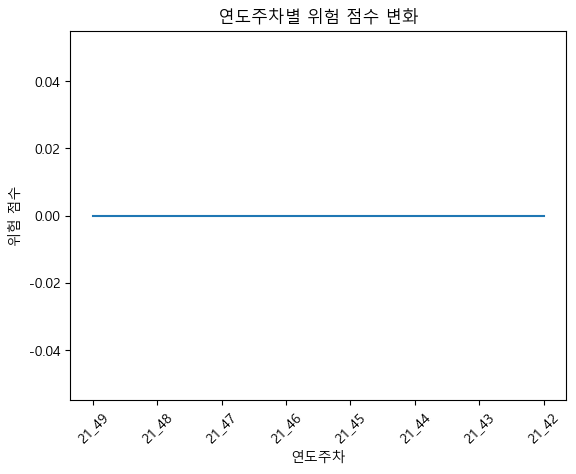

HS Code : 6211499000
21_49주차
📌 estimated initial_level: 87.72781
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 20423.9625
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     96.327
1    102.811
2     85.643
3     87.263
4     79.523
5     78.595
6     73.966
7     69.008
8     70.526
9     63.778
10    80.995
11    96.713
12   101.430
13   110.217
14   102.788
15    87.171
16    82.433
17    80.998
18    71.119
19    75.749
20    73.745
21    67.025
22    69.800
23    62.408
24    57.960
25    56.332
26    55.327
27    59.201
28    60.941
29    67.440
30    66.584
31    67.730
32    67.393
33    66.757
34    73.343
35    74.225
36    84.551
37    96.160
38   104.628
39   114.019
40   117.450
41   110.432
42   100.889
43   105.202
44   109.434
45   118.172
46   118.344
47   127.502
48   136.372
49   145.321
50   164.524
Name: 단가, dtype: float64
📌📌 0      8.599
1     14.223
2     -4.367
3     -2.310
4     -9.819
5     -9.765
6    -13.418
7    -17.034
8    -13.812


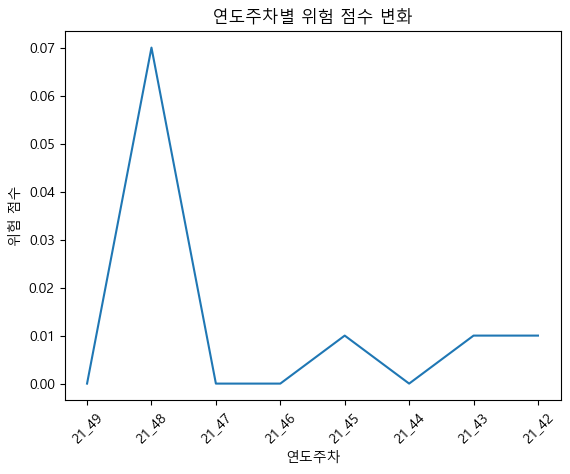

HS Code : 4202999000
21_49주차
📌 estimated initial_level: 35.99246
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2426.0523
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    34.122
1    34.382
2    34.261
3    35.999
4    34.259
5    30.404
6    30.961
7    32.569
8    33.650
9    45.540
10   54.492
11   63.134
12   66.367
13   49.232
14   42.242
15   38.988
16   35.145
17   37.519
18   41.410
19   42.431
20   41.669
21   41.410
22   39.800
23   35.176
24   38.123
25   35.823
26   37.131
27   44.852
28   44.968
29   45.023
30   42.262
31   41.153
32   36.810
33   41.165
34   41.135
35   40.156
36   45.728
37   48.495
38   47.793
39   44.326
40   46.424
41   40.933
42   38.527
43   39.665
44   39.015
45   37.981
46   40.386
47   38.123
48   39.121
49   43.100
50   40.884
Name: 단가, dtype: float64
📌📌 0    -1.870
1    -1.423
2    -1.402
3     0.476
4    -1.311
5    -5.036
6    -3.975
7    -1.970
8    -0.692
9    11.268
10   19.093
11   25.826
12   26.476
13    6.694
1

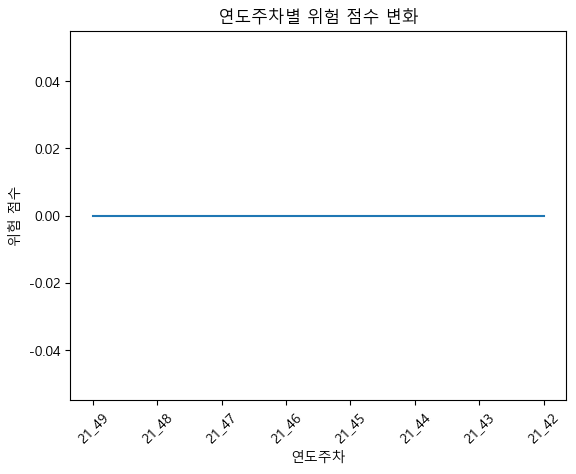

HS Code : 3304991000
21_49주차
📌 estimated initial_level: 89.46671
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2647.2801
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     86.209
1     90.662
2     87.106
3     83.125
4     89.438
5     84.440
6     90.622
7     97.621
8    101.033
9    103.631
10   102.218
11   100.352
12    92.587
13    89.308
14    87.586
15    86.982
16    90.305
17    91.645
18    88.063
19    87.028
20    97.857
21   100.398
22   105.771
23   101.253
24    93.449
25   102.502
26    89.798
27   100.392
28    93.211
29    92.208
30   102.791
31    97.401
32    93.918
33    82.582
34    75.572
35    79.222
36    84.726
37    95.474
38    96.160
39    96.530
40   103.886
41    93.192
42    94.514
43    90.522
44    84.103
45    87.149
46    87.620
47    93.232
48   100.862
49   102.075
50   101.132
Name: 단가, dtype: float64
📌📌 0     -3.258
1      1.521
2     -2.187
3     -5.949
4      0.958
5     -4.135
6      2.461
7      9.213
8     11.704
9

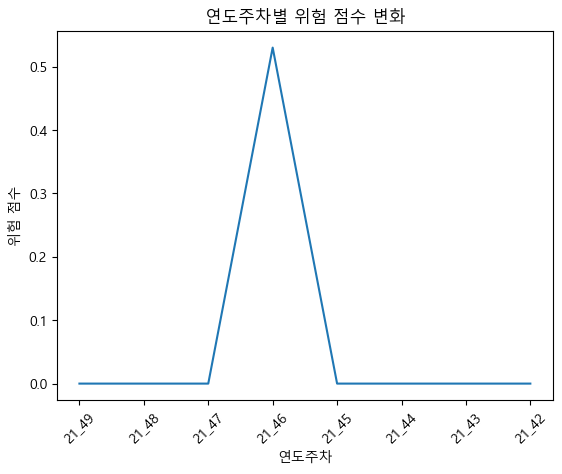

HS Code : 8544429090
21_49주차
📌 estimated initial_level: 32.46942
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 923.2734
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    33.005
1    32.264
2    32.498
3    31.718
4    30.811
5    31.764
6    31.790
7    31.511
8    30.684
9    29.947
10   31.312
11   40.186
12   44.108
13   46.488
14   38.744
15   33.197
16   30.249
17   26.857
18   27.152
19   27.316
20   28.151
21   31.244
22   31.697
23   30.831
24   29.622
25   30.586
26   28.875
27   29.252
28   30.389
29   28.860
30   30.077
31   29.858
32   29.927
33   29.275
34   34.111
35   32.204
36   36.544
37   33.690
38   31.450
39   35.713
40   37.022
41   39.309
42   41.930
43   39.240
44   35.037
45   37.018
46   35.180
47   35.981
48   31.080
49   29.912
50   28.823
Name: 단가, dtype: float64
📌📌 0     0.536
1    -0.259
2     0.001
3    -0.779
4    -1.608
5    -0.495
6    -0.419
7    -0.656
8    -1.418
9    -2.013
10   -0.446
11    8.472
12   11.547
13   12.772
14

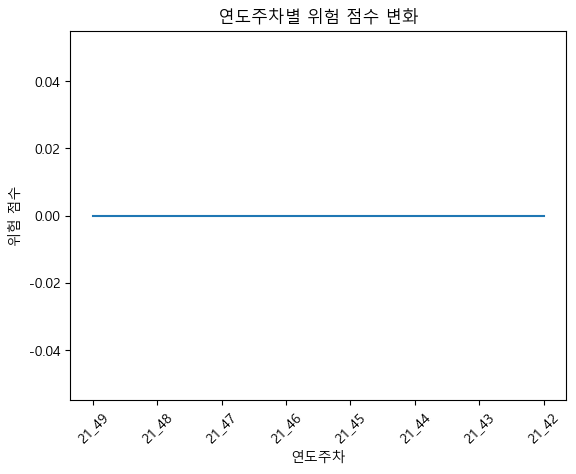

HS Code : 8481801090
21_49주차
📌 estimated initial_level: 26.47111
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 313.2361
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    25.851
1    26.282
2    27.341
3    25.815
4    25.447
5    25.375
6    24.835
7    26.846
8    27.876
9    26.938
10   29.803
11   29.993
12   31.451
13   34.726
14   27.255
15   26.708
16   24.905
17   24.714
18   27.729
19   27.359
20   27.358
21   24.365
22   23.351
23   23.010
24   22.514
25   24.061
26   24.182
27   25.071
28   28.037
29   26.870
30   29.777
31   29.891
32   27.262
33   30.132
34   28.334
35   28.621
36   30.185
37   29.069
38   28.940
39   28.355
40   26.087
41   26.331
42   27.637
43   29.827
44   32.096
45   32.221
46   31.919
47   31.963
48   30.497
49   30.985
50   29.167
Name: 단가, dtype: float64
📌📌 0    -0.620
1    -0.127
2     0.945
3    -0.676
4    -0.976
5    -0.951
6    -1.395
7     0.755
8     1.709
9     0.601
10    3.406
11    3.255
12    4.388
13    7.224
14

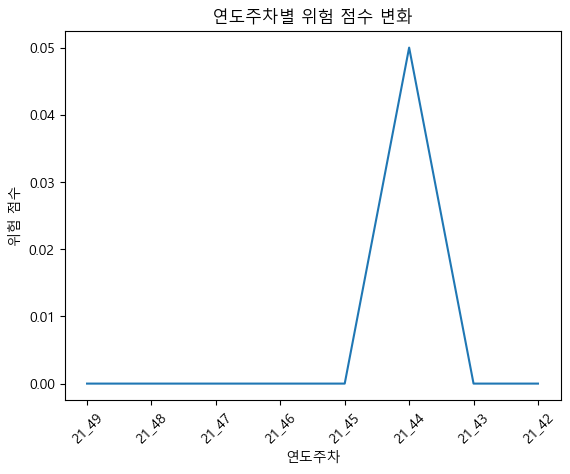

HS Code : 3304999000
21_49주차
📌 estimated initial_level: 87.43627
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3340.2065
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     90.809
1     93.545
2     88.786
3     83.044
4     80.828
5     78.896
6     92.117
7     92.729
8     91.215
9     90.842
10    82.403
11    78.346
12    76.600
13    77.672
14    75.443
15    74.243
16    71.886
17    73.915
18    78.705
19    79.987
20    82.923
21    81.802
22    76.558
23    85.536
24    87.232
25    88.889
26    93.692
27    88.415
28    83.085
29    83.627
30    80.657
31    82.861
32    87.510
33    82.528
34    89.455
35    83.277
36    84.880
37    96.618
38    88.420
39    97.880
40    96.303
41    85.821
42    82.497
43    74.574
44    75.490
45    83.791
46    87.179
47   104.167
48   105.345
49   106.571
50   108.641
Name: 단가, dtype: float64
📌📌 0      3.373
1      5.771
2      0.435
3     -5.350
4     -7.031
5     -8.260
6      5.787
7      5.820
8      3.724
9

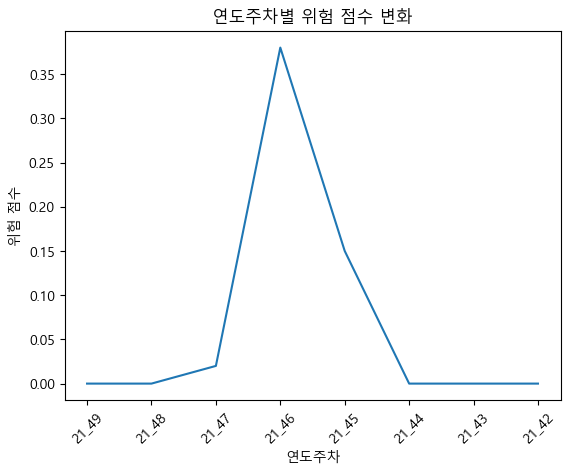

HS Code : 8543709090
21_49주차
📌 estimated initial_level: 187.91756
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 56879.0696
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    185.806
1    175.138
2    187.684
3    180.225
4    187.441
5    214.822
6    206.267
7    200.597
8    193.947
9    171.738
10   168.679
11   174.741
12   213.336
13   226.724
14   242.045
15   248.765
16   198.314
17   169.820
18   168.075
19   166.659
20   156.142
21   159.779
22   142.664
23   130.261
24   121.516
25   120.152
26   110.349
27   110.439
28   112.164
29   106.178
30   109.278
31   110.306
32   108.890
33   113.440
34   121.427
35   130.636
36   150.367
37   154.827
38   170.150
39   171.385
40   167.506
41   181.017
42   189.340
43   180.390
44   193.337
45   217.973
46   186.991
47   211.707
48   224.265
49   190.379
50   208.686
Name: 단가, dtype: float64
📌📌 0     -2.112
1    -12.569
2      1.234
3     -6.348
4      1.502
5     28.733
6     17.305
7      9.905
8      2.264

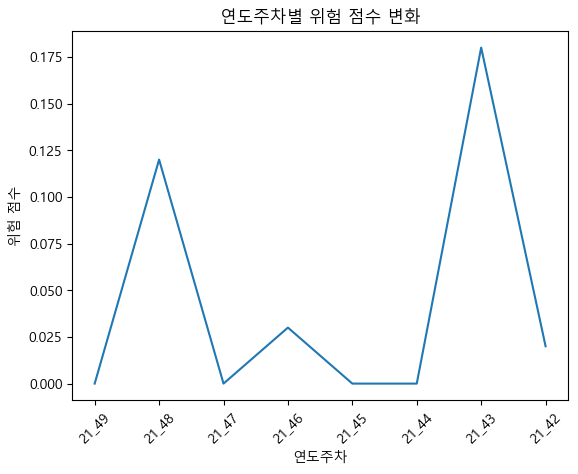

HS Code : 6404199000
21_49주차
📌 estimated initial_level: 26.56147
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 165.6623
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    26.107
1    26.332
2    27.300
3    27.052
4    27.120
5    26.879
6    26.282
7    24.838
8    25.147
9    26.510
10   26.764
11   29.931
12   29.733
13   28.611
14   27.297
15   26.070
16   25.384
17   23.329
18   22.967
19   22.176
20   21.762
21   22.408
22   23.019
23   23.241
24   24.135
25   25.168
26   26.675
27   26.259
28   25.973
29   26.258
30   25.590
31   27.248
32   27.612
33   27.337
34   25.865
35   24.969
36   24.645
37   23.625
38   23.983
39   23.247
40   23.144
41   22.715
42   22.672
43   23.052
44   22.798
45   23.146
46   22.770
47   22.460
48   22.579
49   23.060
50   23.676
Name: 단가, dtype: float64
📌📌 0    -0.454
1    -0.184
2     0.802
3     0.474
4     0.495
5     0.204
6    -0.413
7    -1.815
8    -1.326
9     0.171
10    0.407
11    3.534
12    2.982
13    1.562
14

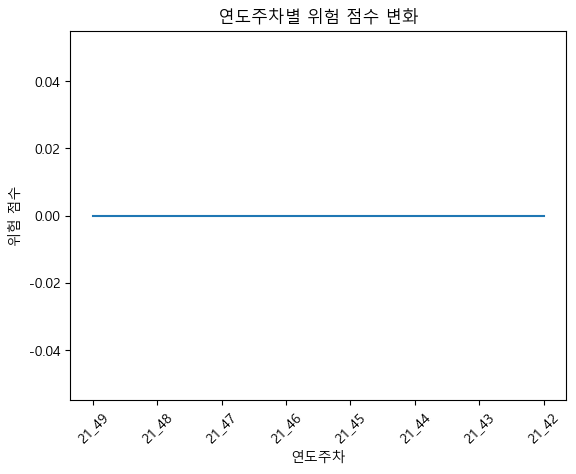

HS Code : 3004909900
21_49주차
📌 estimated initial_level: 59.92109
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 2419.3416
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    72.796
1    72.107
2    57.935
3    42.160
4    43.867
5    50.219
6    53.415
7    57.702
8    59.048
9    63.257
10   60.350
11   62.814
12   64.728
13   51.076
14   58.894
15   52.509
16   47.063
17   59.577
18   55.215
19   58.703
20   66.742
21   55.482
22   62.488
23   61.766
24   57.237
25   59.045
26   55.729
27   52.862
28   56.255
29   63.097
30   61.379
31   59.834
32   63.857
33   53.727
34   53.481
35   58.276
36   52.408
37   53.161
38   55.121
39   49.323
40   48.118
41   47.538
42   46.265
43   52.151
44   53.245
45   58.752
46   55.915
47   59.597
48   66.250
49   66.192
50   68.993
Name: 단가, dtype: float64
📌📌 0     12.875
1     10.899
2     -4.363
3    -19.703
4    -16.025
5     -8.070
6     -4.068
7      0.627
8      1.910
9      5.927
10     2.428
11     4.649
12     6.098


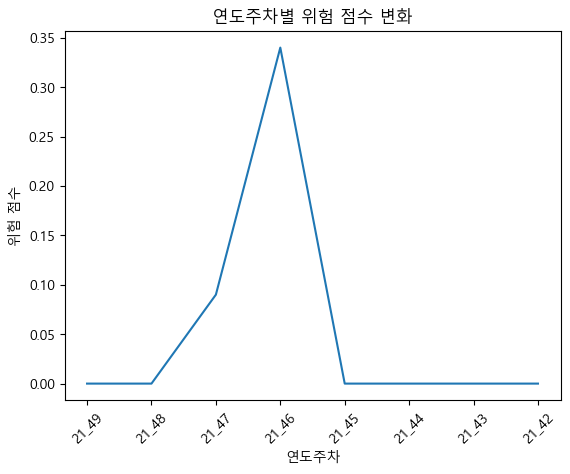

HS Code : 8542311000
21_49주차
📌 estimated initial_level: 5931.21338
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 11858160.0069
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    5897.716
1    5861.924
2    5773.649
3    5821.261
4    5857.884
5    6034.880
6    5998.963
7    6075.663
8    6039.670
9    6257.799
10   5971.406
11   5941.204
12   5860.112
13   5708.886
14   5810.848
15   6049.501
16   7027.921
17   6761.460
18   6853.300
19   7193.001
20   7027.247
21   6992.967
22   7330.021
23   6594.990
24   6515.657
25   7125.140
26   6957.356
27   7681.144
28   7616.440
29   7337.001
30   7427.584
31   6919.421
32   6529.009
33   6529.001
34   6443.433
35   6234.506
36   6100.187
37   5957.534
38   5985.596
39   6074.701
40   6270.972
41   6157.426
42   6278.861
43   6171.803
44   6083.133
45   6015.000
46   5737.255
47   5797.395
48   5904.524
49   6124.873
50   6244.684
Name: 단가, dtype: float64
📌📌 0     -33.498
1     -65.940
2    -147.621
3     -85.246
4    

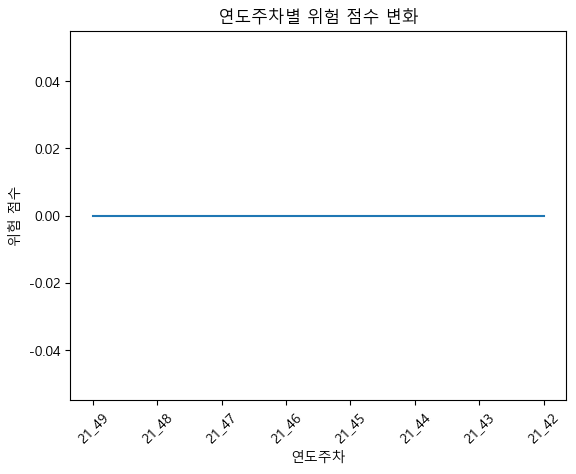

HS Code : 4901999000
21_49주차
📌 estimated initial_level: 18.22211
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 98.9581
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    17.773
1    18.268
2    18.230
3    16.762
4    18.023
5    17.131
6    19.855
7    19.629
8    20.078
9    20.758
10   18.398
11   19.621
12   18.932
13   18.715
14   18.463
15   17.863
16   18.134
17   17.406
18   18.422
19   19.333
20   17.770
21   18.294
22   18.096
23   17.033
24   18.093
25   18.971
26   18.037
27   19.325
28   19.567
29   19.201
30   20.917
31   20.649
32   20.510
33   20.395
34   19.203
35   20.015
36   20.523
37   18.392
38   18.243
39   18.380
40   17.349
41   18.436
42   18.164
43   18.141
44   19.173
45   20.736
46   21.396
47   22.489
48   22.892
49   23.189
50   22.876
Name: 단가, dtype: float64
📌📌 0    -0.449
1     0.091
2     0.044
3    -1.429
4    -0.025
5    -0.914
6     1.901
7     1.485
8     1.786
9     2.287
10   -0.302
11    0.952
12    0.167
13   -0.066
14 

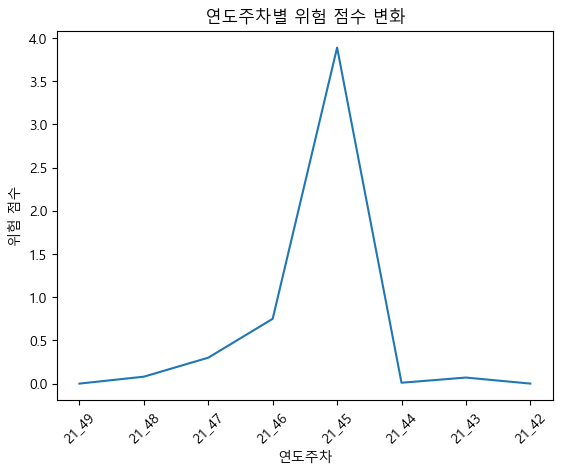

HS Code : 8473309090
21_49주차
📌 estimated initial_level: 122.16646
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 22534.3793
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    116.975
1    119.995
2    129.909
3    128.393
4    113.742
5    109.996
6    107.696
7    105.213
8    108.393
9    124.189
10   149.396
11   156.130
12   161.192
13   179.458
14   158.973
15   151.916
16   160.053
17   135.055
18   123.243
19   126.628
20   103.421
21   102.523
22   104.975
23   101.953
24   125.612
25   125.336
26   132.466
27   136.789
28   149.625
29   157.319
30   167.218
31   168.500
32   172.812
33   177.887
34   174.864
35   168.911
36   164.509
37   159.592
38   152.232
39   158.485
40   132.298
41   127.672
42   154.763
43   156.874
44   154.148
45   154.734
46   156.252
47   150.455
48   163.778
49   187.395
50   160.073
Name: 단가, dtype: float64
📌📌 0     -5.192
1     -1.653
2      8.427
3      6.068
4     -9.189
5    -12.017
6    -13.115
7    -14.287
8     -9.678

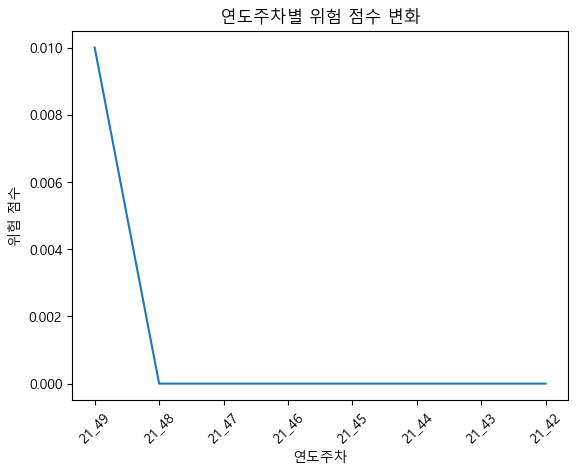

HS Code : 6307909000
21_49주차
📌 estimated initial_level: 9.37359
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 12.0825
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     9.547
1     9.611
2     9.595
3     9.457
4     9.841
5     9.571
6     9.180
7     8.332
8     7.836
9     8.226
10    8.828
11    9.895
12   10.217
13    9.504
14    8.929
15    8.419
16    8.443
17    8.362
18    8.549
19    8.373
20    8.222
21    8.435
22    8.692
23    8.929
24    8.953
25    9.085
26    8.744
27    8.699
28    8.699
29    8.687
30    8.444
31    8.566
32    8.676
33    8.561
34    8.888
35    9.112
36    9.393
37    9.190
38    9.037
39    8.809
40    8.703
41    8.859
42    9.323
43    9.419
44    8.898
45    9.191
46    9.045
47    8.942
48    9.002
49    8.622
50    8.304
Name: 단가, dtype: float64
📌📌 0     0.174
1     0.220
2     0.182
3     0.026
4     0.407
5     0.097
6    -0.304
7    -1.122
8    -1.506
9    -0.965
10   -0.266
11    0.827
12    1.067
13    0.247
14  

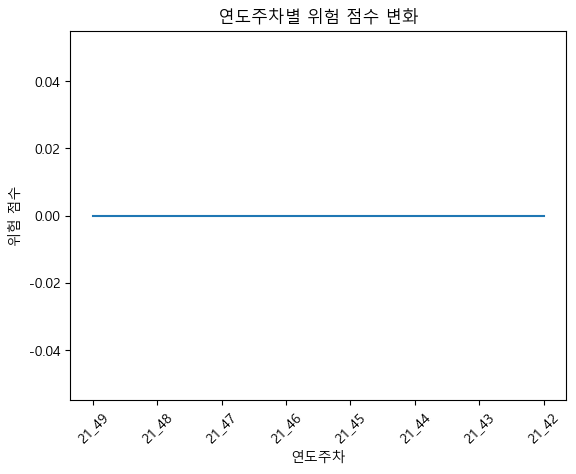

HS Code : 4202211090
21_49주차
📌 estimated initial_level: 534.67397
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 190697.2986
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    532.888
1    562.267
2    559.074
3    594.320
4    562.698
5    511.775
6    480.364
7    407.497
8    387.076
9    408.303
10   444.226
11   579.200
12   632.317
13   633.766
14   611.083
15   576.630
16   585.641
17   551.504
18   538.231
19   499.418
20   518.520
21   518.526
22   526.152
23   551.234
24   539.571
25   517.689
26   548.410
27   547.065
28   539.563
29   581.856
30   534.638
31   545.491
32   552.816
33   550.585
34   564.913
35   515.215
36   510.957
37   472.780
38   430.172
39   404.045
40   391.638
41   369.524
42   417.996
43   532.298
44   504.559
45   555.486
46   505.680
47   463.503
48   491.484
49   514.371
50   518.964
Name: 단가, dtype: float64
📌📌 0      -1.786
1      27.772
2      21.802
3      54.867
4      17.759
5     -34.941
6     -62.858
7    -129.438
8  

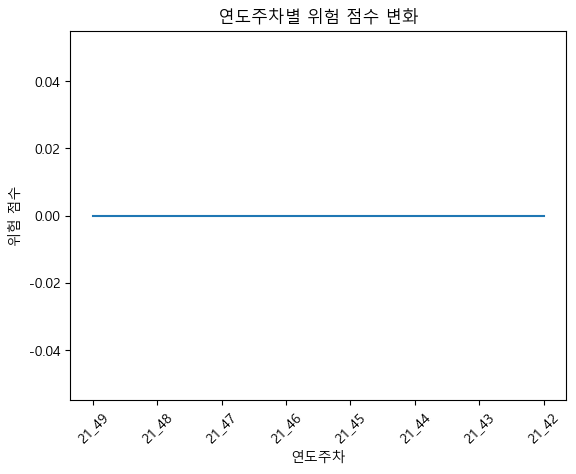

HS Code : 8536509090
21_49주차
📌 estimated initial_level: 78.54323
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3557.1758
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    85.099
1    82.137
2    78.638
3    69.344
4    72.158
5    71.439
6    69.392
7    71.418
8    72.657
9    76.307
10   85.275
11   93.516
12   91.223
13   94.811
14   90.528
15   93.330
16   84.828
17   79.927
18   76.219
19   72.972
20   76.040
21   80.754
22   97.287
23   96.739
24   97.849
25   95.330
26   84.542
27   81.667
28   83.073
29   81.083
30   79.433
31   82.349
32   80.432
33   79.090
34   79.353
35   77.382
36   69.909
37   72.651
38   73.838
39   75.369
40   80.473
41   80.186
42   84.189
43   83.043
44   86.676
45   97.034
46   91.014
47   98.956
48   98.024
49   87.348
50   84.222
Name: 단가, dtype: float64
📌📌 0      6.556
1      2.938
2     -0.855
3    -10.063
4     -6.243
5     -6.338
6     -7.751
7     -4.950
8     -3.216
9      0.755
10     9.648
11    16.924
12    12.940


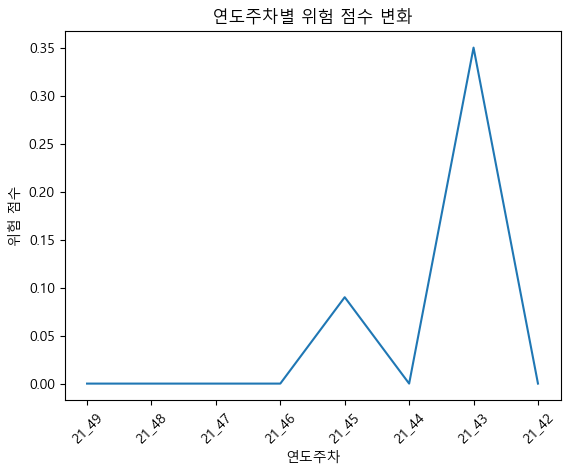

HS Code : 8538909000
21_49주차
📌 estimated initial_level: 44.33006
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 236.4715
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    44.517
1    44.468
2    45.969
3    41.606
4    41.303
5    41.855
6    44.280
7    44.402
8    47.252
9    47.261
10   47.157
11   47.639
12   46.980
13   46.245
14   44.880
15   46.484
16   46.653
17   45.336
18   44.233
19   45.809
20   44.076
21   46.153
22   48.046
23   45.465
24   48.912
25   48.933
26   48.667
27   48.262
28   47.099
29   47.629
30   47.328
31   49.162
32   45.950
33   45.796
34   44.813
35   43.603
36   45.402
37   45.389
38   46.317
39   44.513
40   43.664
41   41.954
42   41.529
43   43.033
44   43.300
45   43.901
46   47.470
47   48.566
48   50.086
49   48.073
50   43.266
Name: 단가, dtype: float64
📌📌 0     0.187
1     0.119
2     1.608
3    -2.915
4    -2.927
5    -2.082
6     0.551
7     0.618
8     3.406
9     3.074
10    2.664
11    2.879
12    1.932
13    1.003
14

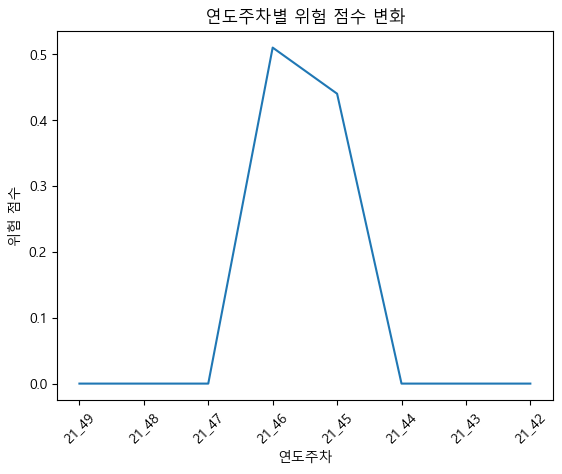

HS Code : 8479909090
21_49주차
📌 estimated initial_level: 61.58999
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 19196.5612
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     64.157
1     62.357
2     61.663
3     61.273
4     55.378
5     59.379
6     49.154
7     49.234
8     48.910
9     49.231
10    65.946
11    72.278
12    86.389
13   117.158
14   132.569
15    99.392
16    81.133
17    53.975
18    44.030
19    44.517
20    33.962
21    37.538
22    41.488
23    42.419
24    68.942
25    64.212
26    68.428
27    73.599
28    76.181
29    85.475
30    84.109
31    87.860
32    86.586
33    79.431
34    71.496
35    62.311
36    45.071
37    45.827
38    44.331
39    43.439
40    52.496
41    51.583
42    52.871
43    60.567
44    61.039
45    49.894
46    57.751
47    60.865
48    57.898
49    67.700
50    66.052
Name: 단가, dtype: float64
📌📌 0      2.567
1      0.510
2     -0.234
3     -0.601
4     -6.436
5     -1.791
6    -11.838
7    -10.573
8     -9.840


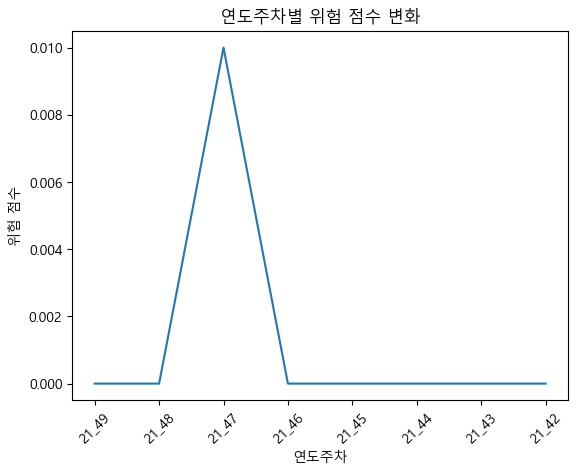

HS Code : 8504409099
21_49주차
📌 estimated initial_level: 54.67295
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 947.4456
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    57.371
1    55.380
2    56.259
3    49.127
4    46.403
5    47.287
6    50.613
7    55.072
8    58.554
9    62.636
10   57.057
11   61.944
12   65.624
13   65.674
14   65.911
15   62.710
16   61.841
17   59.745
18   58.933
19   56.677
20   57.154
21   54.684
22   55.870
23   58.598
24   55.352
25   59.309
26   59.674
27   62.783
28   64.598
29   63.587
30   65.332
31   62.849
32   60.227
33   64.155
34   60.945
35   60.127
36   59.616
37   58.937
38   57.624
39   56.870
40   59.037
41   56.394
42   61.257
43   60.718
44   58.303
45   59.012
46   54.035
47   57.603
48   62.106
49   61.445
50   67.145
Name: 단가, dtype: float64
📌📌 0     2.698
1     0.437
2     1.272
3    -5.987
4    -8.112
5    -6.417
6    -2.449
7     2.255
8     5.511
9     9.042
10    2.558
11    7.190
12   10.151
13    9.185
14

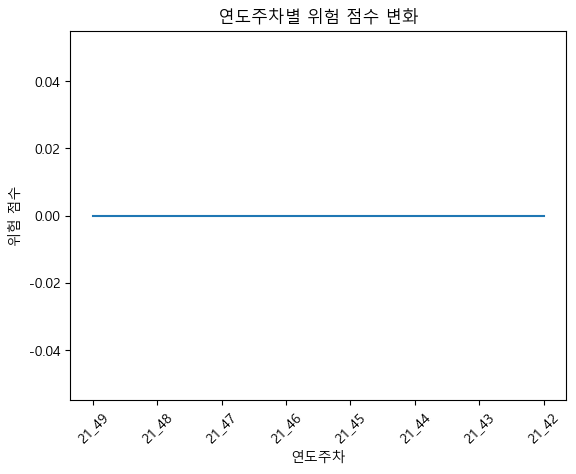

HS Code : 6110909000
21_49주차
📌 estimated initial_level: 216.47206
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 82844.6280
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    230.083
1    223.795
2    221.519
3    220.911
4    215.150
5    213.682
6    201.197
7    190.919
8    187.096
9    203.584
10   209.001
11   212.172
12   222.675
13   205.204
14   205.717
15   205.161
16   203.507
17   161.331
18   135.862
19   127.686
20   128.000
21   146.982
22   192.656
23   232.298
24   238.980
25   269.959
26   273.808
27   279.394
28   266.955
29   258.400
30   263.276
31   249.477
32   243.947
33   230.844
34   207.815
35   216.129
36   196.998
37   176.285
38   159.754
39   130.254
40   126.816
41   128.006
42   120.542
43   131.173
44   151.910
45   159.887
46   171.356
47   179.326
48   173.626
49   179.574
50   198.118
Name: 단가, dtype: float64
📌📌 0     13.611
1      5.962
2      3.089
3      2.173
4     -3.806
5     -4.893
6    -16.889
7    -25.478
8    -26.753

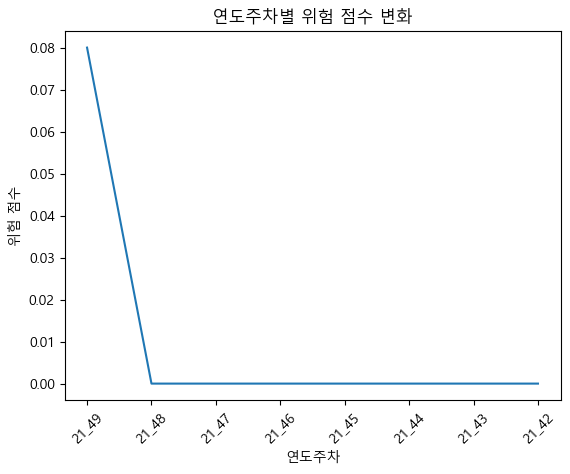

HS Code : 3923100000
21_49주차
📌 estimated initial_level: 3.95068
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1.9458
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    3.784
1    3.863
2    3.893
3    4.086
4    4.202
5    4.231
6    4.255
7    3.998
8    4.134
9    3.977
10   3.924
11   3.838
12   3.621
13   3.564
14   3.571
15   3.623
16   3.708
17   3.721
18   3.709
19   3.758
20   3.701
21   3.777
22   3.768
23   3.754
24   3.745
25   3.721
26   3.823
27   3.787
28   3.772
29   3.759
30   3.672
31   3.765
32   3.852
33   3.944
34   4.054
35   4.054
36   4.080
37   4.045
38   3.977
39   4.052
40   4.139
41   4.122
42   4.391
43   4.294
44   4.338
45   4.386
46   4.264
47   4.131
48   3.954
49   3.873
50   3.781
Name: 단가, dtype: float64
📌📌 0    -0.166
1    -0.071
2    -0.034
3     0.162
4     0.263
5     0.265
6     0.263
7    -0.021
8     0.118
9    -0.052
10   -0.100
11   -0.176
12   -0.374
13   -0.395
14   -0.348
15   -0.261
16   -0.150
17   -0.122
18   -0.

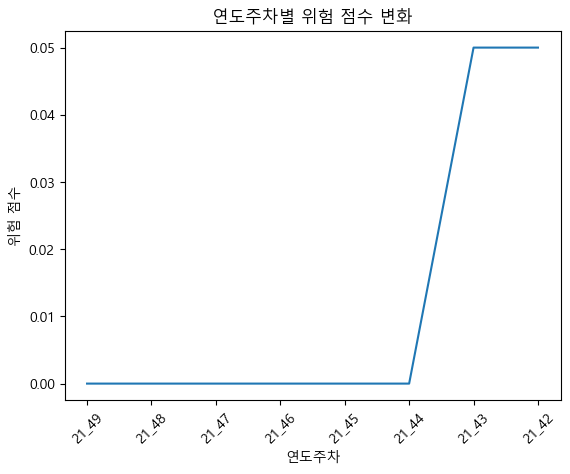

HS Code : 8544422090
21_49주차
📌 estimated initial_level: 18.4547
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 19.7627
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    18.150
1    18.275
2    18.896
3    18.444
4    17.789
5    18.320
6    17.953
7    18.371
8    19.266
9    19.051
10   19.459
11   20.049
12   19.321
13   19.410
14   19.554
15   18.859
16   19.067
17   18.707
18   18.396
19   18.062
20   17.683
21   18.073
22   17.843
23   18.486
24   18.727
25   18.048
26   18.282
27   18.524
28   18.565
29   18.714
30   19.329
31   18.759
32   19.044
33   19.447
34   18.185
35   18.060
36   18.017
37   17.750
38   18.403
39   18.933
40   18.584
41   19.038
42   18.972
43   18.469
44   19.475
45   19.720
46   19.434
47   20.475
48   19.686
49   19.832
50   19.172
Name: 단가, dtype: float64
📌📌 0    -0.305
1    -0.149
2     0.486
3    -0.014
4    -0.668
5    -0.070
6    -0.430
7     0.031
8     0.923
9     0.616
10    0.962
11    1.456
12    0.582
13    0.614
14  

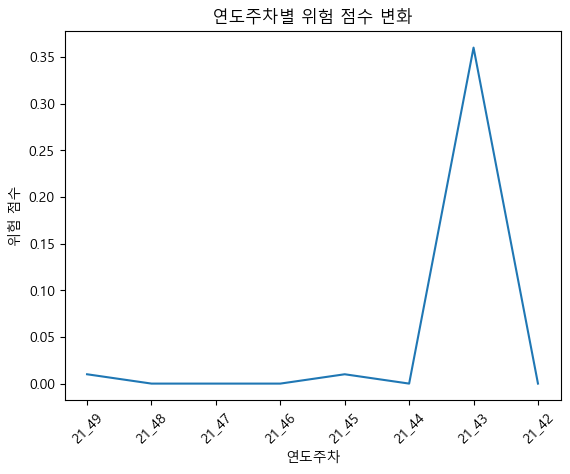

HS Code : 8537109000
21_49주차
📌 estimated initial_level: 115.25333
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3776.8305
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    121.533
1    119.151
2    121.484
3    109.484
4    103.164
5    112.247
6    105.113
7    106.896
8    105.495
9    100.688
10   108.479
11   107.766
12   130.263
13   141.074
14   136.860
15   140.723
16   121.952
17   117.837
18   116.896
19   127.843
20   112.688
21   120.568
22   118.297
23   106.699
24   129.171
25   117.856
26   120.825
27   120.359
28   117.090
29   117.314
30   120.714
31   119.751
32   121.220
33   121.785
34   114.615
35   118.646
36   119.103
37   118.774
38   114.379
39   115.288
40   110.967
41   108.241
42   113.204
43   111.172
44   108.772
45   112.590
46   116.501
47   114.967
48   125.424
49   108.517
50   114.129
Name: 단가, dtype: float64
📌📌 0      6.280
1      3.270
2      5.276
3     -7.252
4    -12.847
5     -2.479
6     -9.366
7     -6.646
8     -7.382


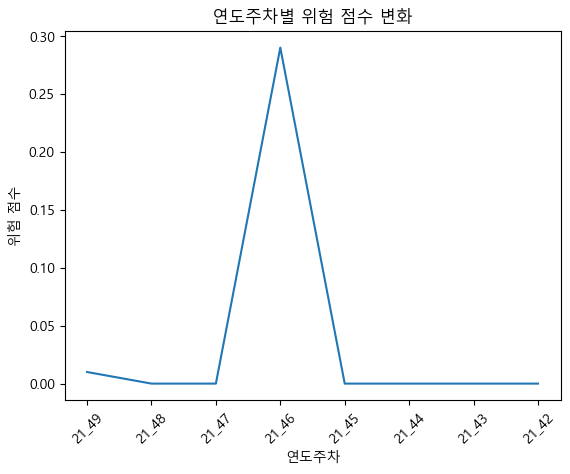

HS Code : 8536699000
21_49주차
📌 estimated initial_level: 37.13373
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 382.2543
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    39.716
1    39.465
2    36.673
3    36.482
4    33.927
5    32.773
6    36.297
7    34.217
8    33.531
9    34.163
10   33.269
11   39.946
12   42.713
13   42.639
14   42.488
15   38.892
16   37.374
17   37.257
18   36.511
19   35.134
20   37.554
21   36.604
22   34.946
23   36.903
24   36.012
25   37.228
26   42.078
27   39.141
28   35.843
29   35.608
30   33.002
31   32.177
32   34.251
33   32.591
34   35.432
35   38.719
36   37.138
37   38.715
38   36.827
39   37.694
40   37.051
41   39.277
42   38.969
43   35.232
44   39.793
45   40.547
46   37.076
47   39.193
48   36.843
49   33.335
50   35.026
Name: 단가, dtype: float64
📌📌 0     2.583
1     2.073
2    -0.926
3    -1.025
4    -3.477
5    -4.283
6    -0.331
7    -2.378
8    -2.827
9    -1.911
10   -2.614
11    4.324
12    6.659
13    5.919
14

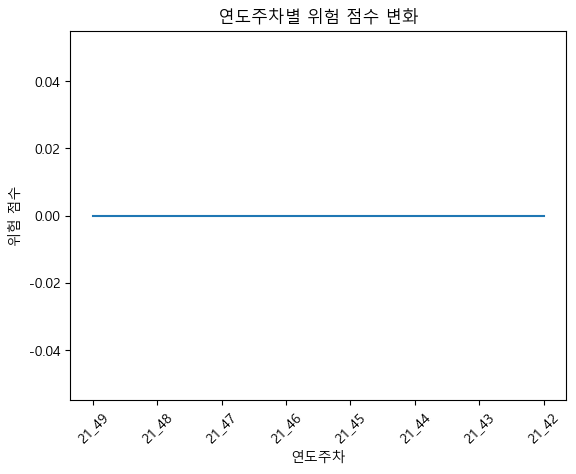

HS Code : 3102109000
21_14주차
📌 estimated initial_level: 0.27053
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0144
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.274
1    0.275
2    0.273
3    0.273
4    0.271
5    0.269
6    0.268
7    0.266
8    0.263
9    0.263
10   0.261
11   0.258
12   0.257
13   0.254
14   0.252
15   0.253
16   0.254
17   0.254
18   0.254
19   0.254
20   0.256
21   0.268
22   0.274
23   0.278
24   0.276
25   0.275
26   0.273
27   0.276
28   0.277
29   0.278
30   0.281
31   0.284
32   0.285
33   0.285
34   0.287
35   0.287
36   0.302
37   0.307
38   0.308
39   0.310
40   0.304
41   0.304
42   0.306
43   0.310
44   0.312
45   0.320
46   0.329
47   0.332
48   0.341
49   0.347
50   0.351
Name: 단가, dtype: float64
📌📌 0     0.004
1     0.004
2     0.002
3     0.001
4    -0.001
5    -0.002
6    -0.003
7    -0.005
8    -0.007
9    -0.007
10   -0.008
11   -0.010
12   -0.011
13   -0.012
14   -0.013
15   -0.011
16   -0.009
17   -0.008
18   -0.

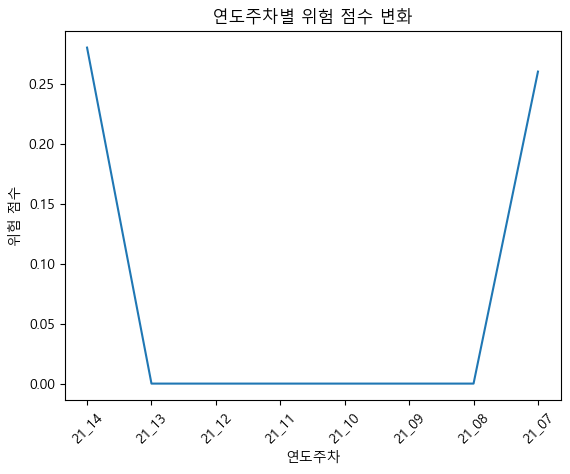

HS Code : 3707901010
19_04주차
📌 estimated initial_level: 273.30148
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 29444.2613
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    271.040
1    293.099
2    289.509
3    292.766
4    282.884
5    235.897
6    226.780
7    230.105
8    229.657
9    289.352
10   281.922
11   292.480
12   276.840
13   265.564
14   274.529
15   272.450
16   271.794
17   249.537
18   275.049
19   264.655
20   275.712
21   263.955
22   257.525
23   258.863
24   226.261
25   260.158
26   232.394
27   239.664
28   243.658
29   241.069
30   270.627
31   241.770
32   275.102
33   270.882
34   274.426
35   273.856
36   243.639
37   240.823
38   231.794
39   251.146
40   277.998
41   272.614
42   292.676
43   274.076
44   287.220
45   326.250
46   296.285
47   286.282
48   246.525
49   210.616
50   234.737
Name: 단가, dtype: float64
📌📌 0     -2.262
1     20.024
2     14.431
3     16.245
4      4.739
5    -42.723
6    -47.567
7    -39.485
8    -35.985

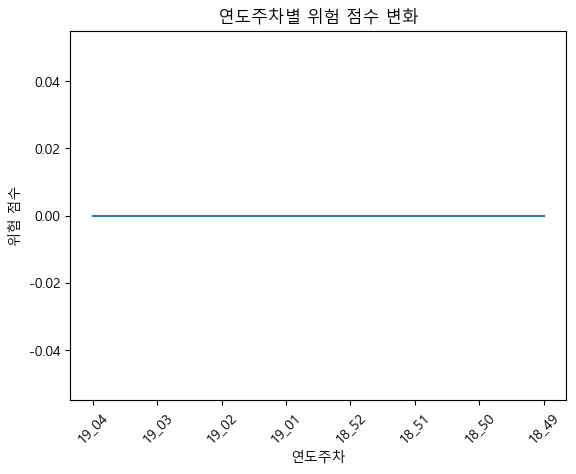

HS Code : 4407191000
20_41주차
📌 estimated initial_level: 1.2064
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.1608
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    1.121
1    1.127
2    1.129
3    1.277
4    1.320
5    1.341
6    1.338
7    1.299
8    1.252
9    1.252
10   1.259
11   1.247
12   1.240
13   1.188
14   1.127
15   1.129
16   1.127
17   1.160
18   1.237
19   1.268
20   1.253
21   1.261
22   1.290
23   1.208
24   1.205
25   1.207
26   1.168
27   1.273
28   1.278
29   1.296
30   1.307
31   1.282
32   1.246
33   1.225
34   1.222
35   1.217
36   1.240
37   1.241
38   1.239
39   1.256
40   1.291
41   1.279
42   1.276
43   1.256
44   1.236
45   1.272
46   1.268
47   1.283
48   1.301
49   1.275
50   1.316
Name: 단가, dtype: float64
📌📌 0    -0.085
1    -0.071
2    -0.062
3     0.092
4     0.126
5     0.135
6     0.118
7     0.067
8     0.013
9     0.012
10    0.018
11    0.004
12   -0.003
13   -0.055
14   -0.110
15   -0.097
16   -0.089
17   -0.047
18    0.0

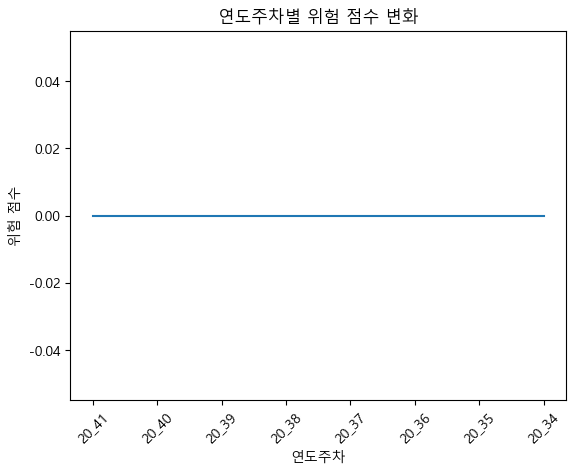

HS Code : 8111000000
21_19주차
📌 estimated initial_level: 1.54399
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 3.3035
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    1.538
1    1.546
2    1.543
3    1.550
4    1.577
5    1.559
6    1.580
7    1.593
8    1.562
9    1.523
10   1.464
11   1.446
12   1.460
13   1.466
14   1.516
15   1.498
16   1.465
17   1.462
18   1.457
19   1.449
20   1.502
21   1.525
22   1.526
23   1.536
24   1.513
25   1.520
26   1.529
27   1.524
28   1.523
29   1.519
30   1.540
31   1.577
32   1.619
33   1.670
34   1.729
35   1.849
36   1.911
37   1.981
38   2.053
39   2.281
40   2.331
41   2.448
42   2.445
43   2.461
44   2.481
45   2.490
46   2.479
47   2.496
48   2.483
49   2.499
50   2.559
Name: 단가, dtype: float64
📌📌 0    -0.006
1     0.002
2    -0.001
3     0.007
4     0.033
5     0.011
6     0.031
7     0.041
8     0.006
9    -0.033
10   -0.089
11   -0.099
12   -0.075
13   -0.061
14   -0.005
15   -0.022
16   -0.053
17   -0.051
18   -0.

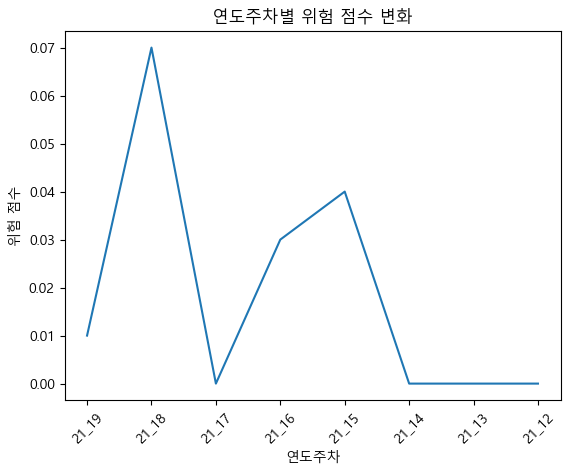

HS Code : 2701129010
21_25주차
📌 estimated initial_level: 0.10468
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0033
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.105
1    0.106
2    0.109
3    0.105
4    0.104
5    0.104
6    0.100
7    0.104
8    0.107
9    0.104
10   0.104
11   0.096
12   0.098
13   0.097
14   0.097
15   0.100
16   0.095
17   0.096
18   0.101
19   0.105
20   0.105
21   0.104
22   0.111
23   0.106
24   0.107
25   0.107
26   0.103
27   0.107
28   0.107
29   0.110
30   0.113
31   0.116
32   0.116
33   0.126
34   0.122
35   0.119
36   0.127
37   0.123
38   0.136
39   0.134
40   0.131
41   0.127
42   0.116
43   0.115
44   0.130
45   0.130
46   0.130
47   0.131
48   0.120
49   0.128
50   0.134
Name: 단가, dtype: float64
📌📌 0    -0.000
1     0.001
2     0.004
3     0.000
4    -0.001
5    -0.001
6    -0.005
7    -0.001
8     0.003
9    -0.001
10   -0.000
11   -0.009
12   -0.006
13   -0.006
14   -0.006
15   -0.002
16   -0.006
17   -0.005
18   -0.

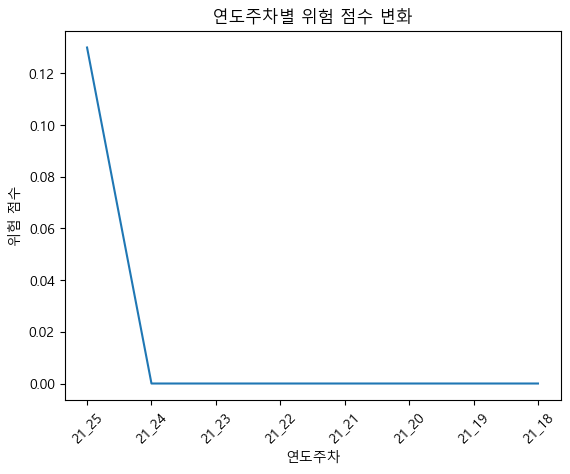

HS Code : 2804701000
21_25주차
📌 estimated initial_level: 3.08166
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1.0194
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    3.132
1    3.061
2    3.033
3    3.104
4    3.077
5    3.083
6    3.106
7    3.078
8    3.124
9    3.050
10   3.092
11   3.035
12   3.008
13   3.051
14   3.076
15   3.085
16   3.012
17   3.027
18   2.965
19   2.976
20   3.003
21   2.965
22   2.951
23   2.920
24   2.930
25   2.884
26   2.941
27   3.446
28   3.332
29   3.499
30   3.310
31   2.799
32   2.863
33   2.831
34   2.821
35   2.890
36   2.824
37   2.865
38   2.883
39   2.876
40   2.908
41   2.917
42   2.906
43   2.891
44   2.912
45   2.931
46   2.909
47   2.869
48   2.830
49   2.816
50   2.820
Name: 단가, dtype: float64
📌📌 0     0.051
1    -0.026
2    -0.051
3     0.025
4    -0.004
5     0.002
6     0.024
7    -0.006
8     0.041
9    -0.037
10    0.009
11   -0.050
12   -0.071
13   -0.021
14    0.006
15    0.014
16   -0.060
17   -0.039
18   -0.

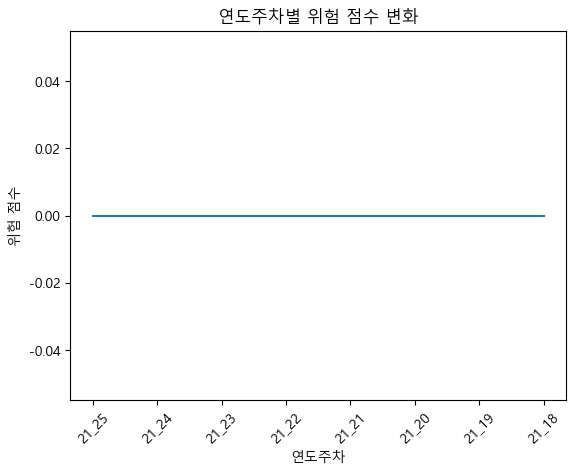

HS Code : 1511901000
21_29주차
📌 estimated initial_level: 0.64408
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.4722
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.621
1    0.643
2    0.646
3    0.620
4    0.620
5    0.633
6    0.627
7    0.642
8    0.653
9    0.646
10   0.699
11   0.680
12   0.695
13   0.698
14   0.730
15   0.771
16   0.784
17   0.794
18   0.788
19   0.843
20   0.879
21   0.869
22   0.869
23   0.905
24   0.919
25   0.948
26   0.938
27   0.929
28   0.964
29   0.970
30   1.038
31   1.039
32   1.047
33   1.055
34   1.030
35   1.030
36   1.033
37   1.022
38   1.038
39   1.037
40   1.030
41   1.036
42   1.043
43   1.050
44   1.048
45   1.040
46   1.088
47   1.083
48   1.091
49   1.091
50   1.162
Name: 단가, dtype: float64
📌📌 0    -0.023
1     0.001
2     0.004
3    -0.022
4    -0.020
5    -0.005
6    -0.011
7     0.005
8     0.016
9     0.008
10    0.060
11    0.034
12    0.046
13    0.044
14    0.072
15    0.106
16    0.109
17    0.107
18    0.

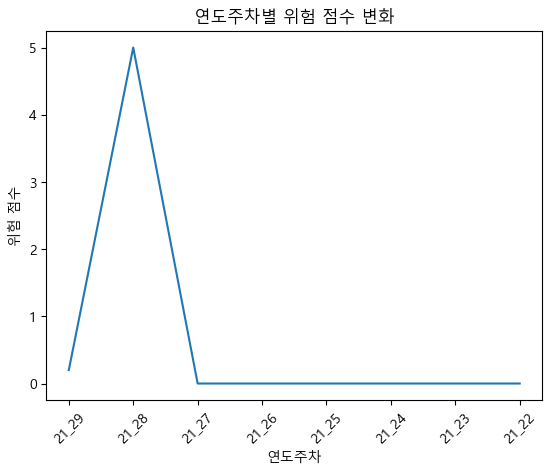

HS Code : 305531000
21_34주차
📌 estimated initial_level: 10.37605
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 5.7081
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    10.457
1    10.291
2    10.331
3    10.352
4    10.652
5    10.680
6    10.556
7    10.204
8    10.238
9     9.965
10    9.833
11   10.247
12   10.184
13   10.669
14   10.382
15   10.074
16   10.266
17    9.824
18   10.194
19   10.391
20    9.905
21    9.881
22    9.969
23    9.967
24    9.942
25   10.309
26   10.195
27   10.037
28   10.390
29   10.453
30   10.162
31    9.852
32    9.621
33    9.196
34    9.350
35    9.638
36   10.013
37    9.977
38   10.147
39   10.167
40    9.490
41    9.620
42    9.601
43    9.705
44   10.421
45   10.462
46   10.554
47   10.553
48   10.477
49   10.527
50   10.073
Name: 단가, dtype: float64
📌📌 0     0.081
1    -0.093
2    -0.044
3    -0.018
4     0.284
5     0.283
6     0.130
7    -0.234
8    -0.177
9    -0.432
10   -0.521
11   -0.055
12   -0.112
13    0.384
14   

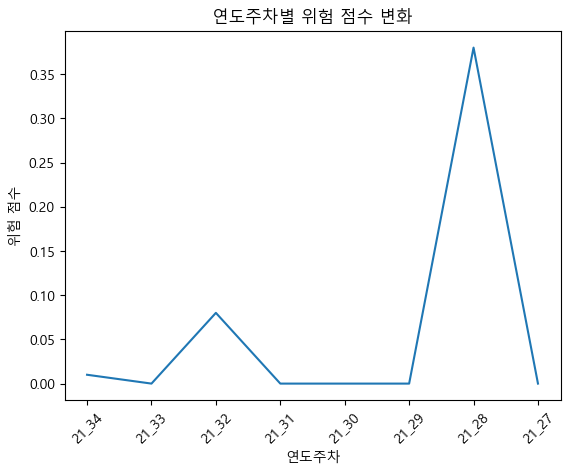

HS Code : 302140000
21_35주차
📌 estimated initial_level: 8.85899
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 51.6284
======================= 여기부터 GARCH 모델링 =================================
📌📌 0     9.204
1     9.142
2     9.207
3     9.397
4     9.213
5     8.929
6     8.595
7     8.103
8     7.817
9     7.567
10    7.347
11    7.301
12    7.314
13    7.361
14    7.389
15    7.522
16    7.879
17    8.235
18    8.375
19    8.449
20    8.298
21    8.031
22    7.962
23    8.044
24    8.228
25    8.719
26    9.300
27    9.672
28    9.979
29   10.184
30   10.329
31   10.529
32   10.716
33   10.961
34   11.144
35   11.442
36   11.862
37   12.057
38   11.951
39   11.591
40   11.142
41   10.882
42   10.815
43   10.860
44   10.877
45   10.978
46   11.150
47   11.291
48   11.276
49   10.982
50   10.477
Name: 단가, dtype: float64
📌📌 0     0.345
1     0.249
2     0.288
3     0.449
4     0.221
5    -0.085
6    -0.411
7    -0.862
8    -1.061
9    -1.205
10   -1.305
11   -1.221
12   -1.085
13   -0.930
14   

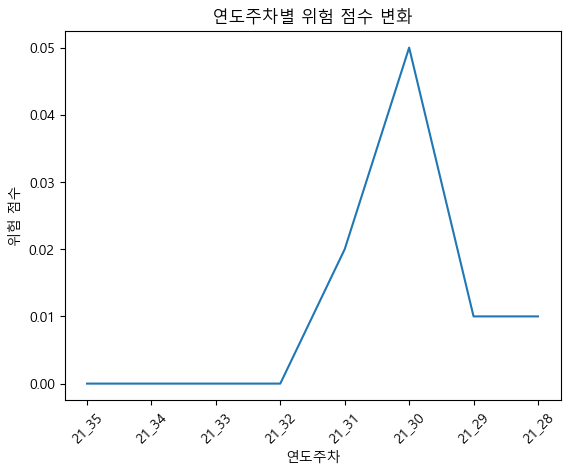

HS Code : 1003901000
21_34주차
📌 estimated initial_level: 0.23955
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0077
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.236
1    0.236
2    0.231
3    0.233
4    0.234
5    0.234
6    0.258
7    0.285
8    0.285
9    0.241
10   0.241
11   0.233
12   0.237
13   0.238
14   0.240
15   0.238
16   0.232
17   0.232
18   0.229
19   0.229
20   0.223
21   0.221
22   0.218
23   0.218
24   0.216
25   0.216
26   0.216
27   0.217
28   0.217
29   0.217
30   0.217
31   0.216
32   0.216
33   0.216
34   0.216
35   0.223
36   0.225
37   0.227
38   0.224
39   0.216
40   0.222
41   0.222
42   0.224
43   0.226
44   0.224
45   0.231
46   0.228
47   0.230
48   0.228
49   0.223
50   0.225
Name: 단가, dtype: float64
📌📌 0    -0.003
1    -0.003
2    -0.008
3    -0.005
4    -0.004
5    -0.003
6     0.021
7     0.046
8     0.041
9    -0.007
10   -0.006
11   -0.013
12   -0.008
13   -0.006
14   -0.004
15   -0.005
16   -0.011
17   -0.010
18   -0.

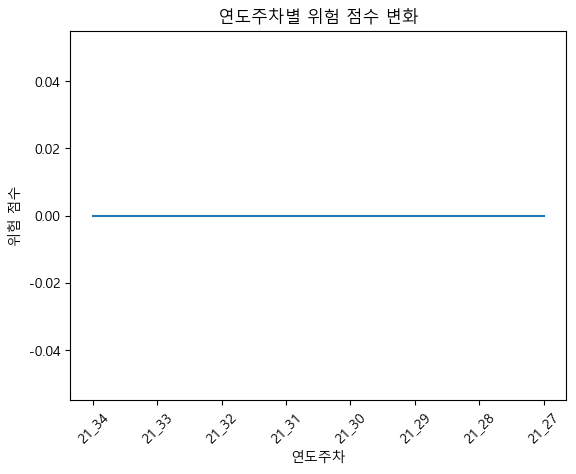

HS Code : 1003902000
21_34주차
📌 estimated initial_level: 0.24744
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0209
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.284
1    0.252
2    0.238
3    0.228
4    0.224
5    0.224
6    0.228
7    0.285
8    0.266
9    0.244
10   0.243
11   0.218
12   0.217
13   0.206
14   0.210
15   0.211
16   0.213
17   0.215
18   0.217
19   0.224
20   0.225
21   0.242
22   0.249
23   0.250
24   0.250
25   0.250
26   0.244
27   0.239
28   0.236
29   0.247
30   0.254
31   0.254
32   0.246
33   0.256
34   0.283
35   0.283
36   0.283
37   0.282
38   0.278
39   0.272
40   0.272
41   0.269
42   0.281
43   0.293
44   0.293
45   0.287
46   0.268
47   0.269
48   0.269
49   0.277
50   0.279
Name: 단가, dtype: float64
📌📌 0     0.037
1     0.001
2    -0.014
3    -0.021
4    -0.024
5    -0.022
6    -0.015
7     0.043
8     0.020
9    -0.004
10   -0.004
11   -0.029
12   -0.028
13   -0.035
14   -0.029
15   -0.024
16   -0.020
17   -0.016
18   -0.

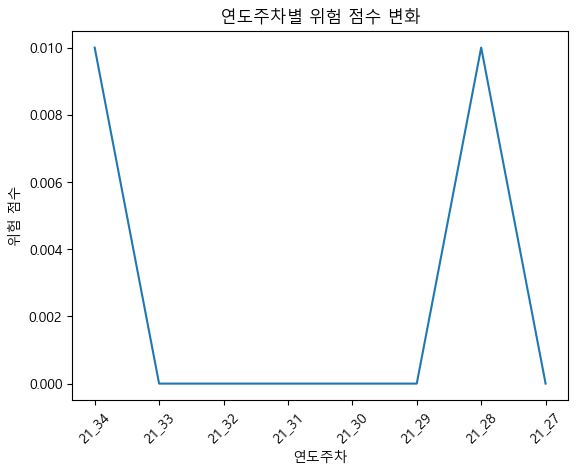

HS Code : 1104230000
21_34주차
📌 estimated initial_level: 0.46708
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 102.0776
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.397
1    0.396
2    0.391
3    0.394
4    0.406
5    0.404
6    0.409
7    0.406
8    0.402
9    0.392
10   0.383
11   0.359
12   0.359
13   0.359
14   0.359
15   0.360
16   6.909
17   8.119
18   0.416
19   0.402
20   0.403
21   0.400
22   0.377
23   0.386
24   0.402
25   0.407
26   0.415
27   0.410
28   0.404
29   0.412
30   0.411
31   0.414
32   0.410
33   0.424
34   0.414
35   0.418
36   0.420
37   0.408
38   0.414
39   0.407
40   0.405
41   0.392
42   0.392
43   0.392
44   0.394
45   0.394
46   0.396
47   0.397
48   0.395
49   0.395
50   0.394
Name: 단가, dtype: float64
📌📌 0    -0.070
1    -0.064
2    -0.063
3    -0.053
4    -0.037
5    -0.034
6    -0.026
7    -0.027
8    -0.028
9    -0.035
10   -0.040
11   -0.060
12   -0.054
13   -0.049
14   -0.044
15   -0.039
16    6.514
17    7.073
18   -

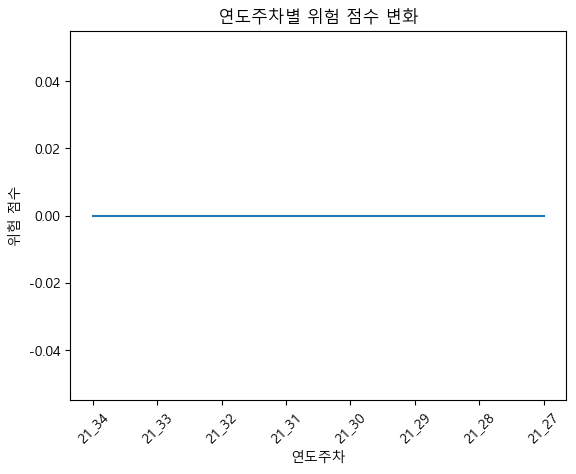

HS Code : 2710121000
21_34주차
📌 estimated initial_level: 0.41748
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.2620
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.425
1    0.427
2    0.425
3    0.423
4    0.424
5    0.415
6    0.395
7    0.388
8    0.388
9    0.386
10   0.382
11   0.382
12   0.387
13   0.395
14   0.402
15   0.405
16   0.410
17   0.435
18   0.481
19   0.480
20   0.460
21   0.485
22   0.482
23   0.505
24   0.530
25   0.556
26   0.557
27   0.587
28   0.587
29   0.598
30   0.633
31   0.647
32   0.646
33   0.642
34   0.633
35   0.622
36   0.633
37   0.634
38   0.663
39   0.658
40   0.527
41   0.571
42   0.570
43   0.559
44   0.679
45   0.687
46   0.724
47   0.730
48   0.733
49   0.733
50   0.732
Name: 단가, dtype: float64
📌📌 0     0.008
1     0.008
2     0.006
3     0.004
4     0.004
5    -0.005
6    -0.025
7    -0.029
8    -0.027
9    -0.026
10   -0.028
11   -0.025
12   -0.017
13   -0.007
14    0.001
15    0.003
16    0.008
17    0.032
18    0.

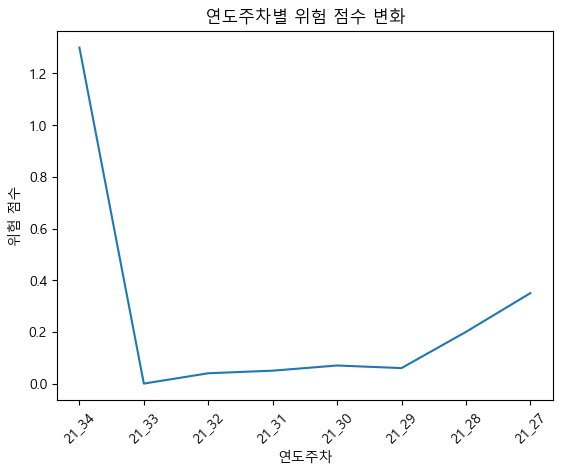

HS Code : 3104200000
21_34주차
📌 estimated initial_level: 0.26724
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 0.0143
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    0.265
1    0.264
2    0.267
3    0.265
4    0.265
5    0.266
6    0.265
7    0.264
8    0.301
9    0.266
10   0.267
11   0.267
12   0.267
13   0.286
14   0.304
15   0.268
16   0.269
17   0.270
18   0.267
19   0.270
20   0.269
21   0.268
22   0.273
23   0.271
24   0.272
25   0.269
26   0.265
27   0.271
28   0.268
29   0.272
30   0.261
31   0.260
32   0.260
33   0.260
34   0.299
35   0.280
36   0.279
37   0.280
38   0.276
39   0.299
40   0.283
41   0.283
42   0.278
43   0.278
44   0.274
45   0.280
46   0.286
47   0.288
48   0.295
49   0.343
50   0.356
Name: 단가, dtype: float64
📌📌 0    -0.002
1    -0.003
2    -0.000
3    -0.002
4    -0.001
5    -0.000
6    -0.002
7    -0.003
8     0.035
9    -0.004
10   -0.002
11   -0.002
12   -0.002
13    0.017
14    0.034
15   -0.006
16   -0.004
17   -0.002
18   -0.

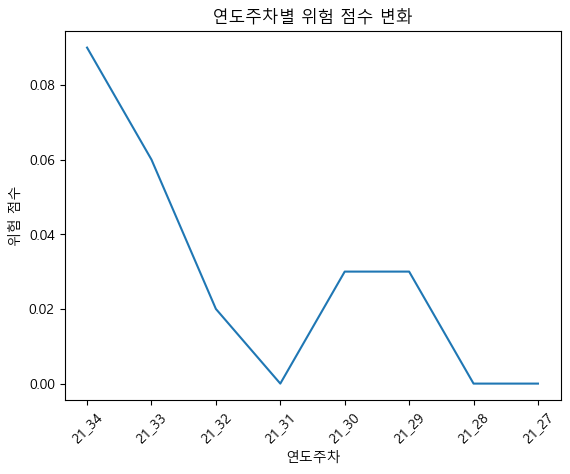

HS Code : 2905172000
21_43주차
📌 estimated initial_level: 1.4735
최적화 (외생변수 없음):
최적 alpha: 0.1000
최소 SSE: 1.7807
======================= 여기부터 GARCH 모델링 =================================
📌📌 0    1.418
1    1.404
2    1.404
3    1.385
4    1.572
5    1.555
6    1.567
7    1.605
8    1.475
9    1.488
10   1.527
11   1.552
12   1.537
13   1.632
14   1.652
15   1.632
16   1.721
17   1.638
18   1.687
19   1.763
20   1.750
21   1.776
22   1.813
23   1.771
24   1.838
25   1.870
26   1.868
27   1.884
28   1.888
29   1.972
30   1.982
31   2.164
32   2.211
33   2.363
34   2.266
35   2.237
36   2.206
37   2.106
38   2.144
39   2.074
40   2.136
41   2.217
42   2.281
43   2.268
44   2.303
45   2.208
46   2.411
47   2.438
48   2.393
49   2.378
50   2.260
Name: 단가, dtype: float64
📌📌 0    -0.055
1    -0.064
2    -0.057
3    -0.071
4     0.123
5     0.094
6     0.096
7     0.125
8    -0.018
9    -0.003
10    0.037
11    0.057
12    0.037
13    0.128
14    0.136
15    0.102
16    0.180
17    0.079
18    0.1

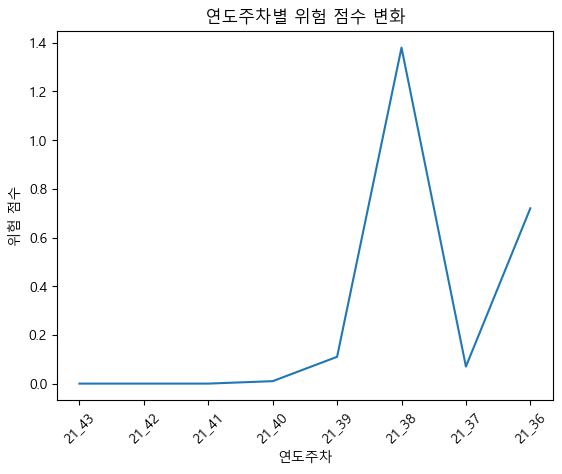

[0, 0, np.float64(0.72), np.float64(0.23), 0, np.float64(0.01), 0, np.float64(0.01), np.float64(0.01), np.float64(0.37), np.float64(1.56), 0, np.float64(0.07), 0, np.float64(0.53), 0, np.float64(0.05), np.float64(0.38), np.float64(0.18), 0, np.float64(0.34), 0, np.float64(3.89), np.float64(0.01), 0, 0, np.float64(0.35), np.float64(0.51), np.float64(0.01), 0, np.float64(0.08), np.float64(0.05), np.float64(0.36), np.float64(0.29), 0, np.float64(0.28), 0, 0, np.float64(0.07), np.float64(0.13), 0, np.float64(5.0), np.float64(0.38), np.float64(0.05), 0, np.float64(0.01), 0, np.float64(1.3), np.float64(0.09), np.float64(1.38)]
[0, 0, 48, 48, 0, 46, 0, 45, 42, 48, 48, 0, 43, 0, 45, 0, 47, 45, 48, 0, 45, 0, 46, 42, 0, 0, 48, 45, 44, 0, 42, 48, 48, 45, 0, 77, 0, 0, 73, 66, 0, 63, 63, 61, 0, 57, 0, 57, 57, 53]
DataFrame 길이: 15
리스트 k 길이: 50


In [3]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
     
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 Exponential Smoothing 구하기 ====================
        res_resid = df_price_4w['단가'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop = True)
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
        
        model = ExponentialSmoothing(train, initialization_method="estimated")
        model_fit = model.fit(smoothing_level=0.2)
        estimated_level = round(model_fit.params["initial_level"], 5)
        print("📌 estimated initial_level:", estimated_level)
            
        print("최적화 (외생변수 없음):")
        result1 = optimize_hw_parameters_fixed_alpha(train, initial_level = estimated_level)
        print(f"최적 alpha: {result1['alpha']:.4f}")
        print(f"최소 SSE: {result1['SSE']:.4f}")

             
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = train - result1['fitted'][:-1]
        #est_residuals = model_fit.resid
        print("📌📌", train)
        print("📌📌", est_residuals)
        
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
               
        stand_quant = (test.iloc[0] - result1['fitted'][-1]) / garch_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        print("📌",test.iloc[0])
        print("📌",result1['fitted'])
        print("📌",result1['fitted'][-1])
        print("📌",garch_std)
        print("📌", y)

      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop = True)
        n_test = 1
        train, test = res_resid[:-n_test], res_resid[-n_test:]
       
        model = ExponentialSmoothing(train, initialization_method="estimated")
        model_fit = model.fit(smoothing_level=0.2)
        estimated_level = round(model_fit.params["initial_level"], 5)
        print("📌 estimated initial_level:", estimated_level)
            
        print("최적화 (외생변수 없음):")
        result1 = optimize_hw_parameters_fixed_alpha(train, initial_level = estimated_level)
        print(f"최적 alpha: {result1['alpha']:.4f}")
        print(f"최소 SSE: {result1['SSE']:.4f}")

              
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = train - result1['fitted'][:-1]
        #est_residuals = model_fit.resid
        
        garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
        garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        
        print('=========== GARCH forecast =============')
        # Use GARCH to predict the residual
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
               
        stand_quant = (test.iloc[0] - result1['fitted'][-1]) / garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y

    if(z[j]<1.85):
        o[j] = 1      
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

print("DataFrame 길이:", len(collect['Model0(1)'].iloc[:-1]))
print("리스트 k 길이:", len(k))

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model8(1)'] = o
collect.loc[50, 'Model8(1)'] = np.sum(o)
collect.loc[:49, 'Model8(2)'] = z
collect.loc[50, 'Model8(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[9]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[9]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[9]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)